[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A9_marketing_mix.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's ninth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A9 (IA) — Marketing Mix & Incrementality: Where the Budget Should Go

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

The B2B webshop from NB 25 — the one A1 priced, A3 lent to and A8 buys for — spends **€2.4 million a year** on marketing, split across six channels. Next year's split is due in three weeks, and the meeting has already gone wrong: the CFO has been reading the analytics dashboard, where **branded search reports a 12× return on ad spend**, and has proposed the obvious thing. *Put the money where the returns are.*

This notebook is about why that sentence, said in good faith by a competent person reading a correct number, would cost the company money. Three of this module's notebooks have already circled the same drain from different sides — A1 showed that a price/volume correlation measures the pricing department's habits, A2 showed how to buy an answer with a randomized test, A4 showed that a naive treated-vs-untreated gap is *effect plus selection bias*. A9 is the version of that problem where the unit of analysis is a **week**, the unit of decision is a **channel budget**, and the deliverable is not a model but an **allocation**: six numbers that add to €2.4 M.

Two things live here that live nowhere else in the module. Marketing spend has **carryover** — the trade show you paid for in March is still producing orders in May — and it has **diminishing returns**: the tenth thousand euros in a channel buys less than the first. A1 optimised one product's price, A2 ran one experiment, A4 targeted one customer at a time. This notebook works at the **aggregate weekly level**, which is both its power (it sees channels no cookie can track) and its curse (156 rows to identify a dozen curves).

> 🧠 **Mental model.** Attribution asks *"who was standing next to the customer when they bought?"* Incrementality asks *"what would have happened if we hadn't done it?"* These are different questions with different answers, and only the second one has money in it. Branded search is standing next to almost every customer — people type your name when they have already decided. Trade shows are standing three weeks and four clicks away, so they get credit for nothing. A marketing-mix model is one attempt at the second question; a geo holdout (§5) is a better one; the honest workflow uses the experiment to calibrate the model.

## 🎯 Learning objectives

By the end you can:

1. Explain why **last-click attribution** systematically over-credits closing channels and starves upper-funnel ones — and why **reverse causality** (spend that follows demand) is a *second, separate* error that better attribution rules cannot fix.
2. Implement the two transforms every marketing-mix model is built from — geometric **adstock** (carryover, with a half-life) and a **saturation curve** (diminishing returns, with a half-saturation point) — and read both off a chart.
3. Fit an MMM: seasonality (Fourier), price, promo and trend controls, non-negative channel coefficients, and a search over the adstock/saturation hyper-parameters — then **backtest it honestly** on held-out weeks.
4. State what 156 weekly observations *cannot* identify, and show it three ways: a channel whose spend never varies, a channel whose spend chases demand, and channels that all move together.
5. Turn coefficients into a decision with **marginal ROAS** and the rule that ends every budget meeting — **equalise marginal returns** — subject to guardrails: bootstrap the curves, never extrapolate past the spend you have actually run, and remember the optimum is flat.
6. Design and price a **geo holdout** that measures incrementality directly: the MDE calculation, the €-cost of the test, and the € it protects.

## ✅ Prerequisites

**A1** (price endogeneity — this notebook is that lesson at the channel level, and §3's controls are A1 §3's controls), **A2** (MDE-first test design; §5 is an A2 experiment in geographic clothing) and **A4** (effect vs selection bias; the incrementality frame). **NB 11** for the Fourier seasonality pair and **NB 10** for confidence intervals. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import lsq_linear, minimize
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

BUDGET       = 2_400_000.0   # annual marketing budget, EUR
WEEKS        = 156           # three years of weekly data
GROSS_MARGIN = 0.36          # blended contribution margin of the catalogue (A1's SKUs)
AOV          = 790.0         # average order value, EUR

print(f"One budget meeting, EUR {BUDGET:,.0f} a year, {WEEKS} weeks of history, "
      f"six channels.\nEvery euro of revenue below carries {GROSS_MARGIN:.0%} of gross margin.")

One budget meeting, EUR 2,400,000 a year, 156 weeks of history, six channels.
Every euro of revenue below carries 36% of gross margin.


## 1. The business: €2.4 M, six channels, one budget meeting

The webshop sells office and IT supplies to German *Mittelstand* companies — NB 25's customer base, A1's catalogue. Marketing runs six channels, and they do genuinely different jobs:

| Channel | What it does | Annual budget |
|---|---|---|
| `brand_search` | bids on the company's own name — people who already know you | €600,000 |
| `nonbrand_search` | bids on *"toner cartridge bulk"* — people with a need and no supplier in mind | €540,000 |
| `paid_social` | LinkedIn/XING campaigns at office managers — nobody is shopping when they see it | €360,000 |
| `display` | retargeting banners at people who have already visited | €480,000 |
| `email` | the weekly newsletter to the existing base | €120,000 |
| `trade_shows` | four industry fairs a year — booth, staff, travel, in two-week lumps | €300,000 |

Because we *simulate* this business, we get A4's superpower again: we plant the truth and then check every estimate against it. Two mechanisms are planted deliberately, and they are the whole notebook.

**Carryover (adstock).** Money spent in week *t* keeps working in weeks *t+1, t+2, …*, decaying geometrically. Email's half-life is a few days — you read it or you don't. A trade show's is weeks: a conversation at the booth becomes a quote in April and an order in May.

**Diminishing returns (saturation).** Each channel's revenue response is a concave curve of (adstocked) spend, flattening as you buy the less and less interested. The **half-saturation point** is the weekly spend at which the channel delivers half of everything it could ever deliver. Cheap, narrow channels saturate early; broad ones have room.

And two mechanisms are planted as **traps**:

- **Branded search harvests demand, it doesn't create it.** Its spend *responds* to demand — auto-bidding buys more clicks in exactly the weeks more people search the company's name, which are exactly the weeks the company was going to sell more anyway. That is A1's price endogeneity wearing a marketing badge.
- **Display retargets people who were already coming back.** Same disease, milder: a big retargeting pool is a *symptom* of a good week, not a cause.

In [2]:
# ── The channel book. `beta` (max weekly EUR the channel could ever deliver),
# `half` (half-saturation spend, EUR/week) and `decay` (weekly adstock carryover)
# are the HIDDEN TRUTH the rest of the notebook has to recover.
CHANNEL_BOOK = {
    "brand_search":    dict(beta=27_000., half= 3_500., decay=0.20, budget=600_000.),
    "nonbrand_search": dict(beta=94_900., half=16_000., decay=0.35, budget=540_000.),
    "paid_social":     dict(beta=66_000., half=10_000., decay=0.55, budget=360_000.),
    "display":         dict(beta=14_600., half= 2_000., decay=0.30, budget=480_000.),
    "email":           dict(beta=27_750., half= 5_000., decay=0.15, budget=120_000.),
    "trade_shows":     dict(beta=59_000., half= 9_000., decay=0.80, budget=300_000.),
}
CHANNELS = list(CHANNEL_BOOK)

BASE_WK    = 245_000.   # organic weekly revenue, before any of this year's marketing
PROMO_LIFT =  18_000.   # A1's flyer weeks: extra EUR/week at the same prices
PRICE_BETA = -196_000.  # EUR lost per +1.00 of the price index (A1's elasticity, in levels)
COMP_BETA  = -110_000.  # EUR lost per +1.00 of the competitor's ad-pressure index
NOISE_SD   =   5_000.   # unexplainable weekly wobble
BRAND_CHASE, DISPLAY_CHASE = 2.6, 0.9   # how hard each channel's spend follows demand


def adstock(spend, decay):
    '''Geometric carryover: x_t = s_t + decay * x_{t-1}, renormalised so that a
    CONSTANT spend maps to the same constant level (keeps `half` interpretable).'''
    out, carry = np.empty(len(spend)), 0.0
    for i, s in enumerate(spend):
        carry = s + decay * carry
        out[i] = carry
    return out * (1 - decay)


def saturate(x, half):
    '''Hill/Michaelis-Menten response: 0 at zero spend, 1/2 at `half`, ->1 eventually.'''
    return x / (x + half)

In [3]:
def build_history(seed=7):
    '''Three years of weekly marketing spend, market conditions and revenue.'''
    rng = np.random.default_rng(seed)
    t = np.arange(WEEKS)
    wk = t % 52

    # ---- market conditions -------------------------------------------------
    season = (0.16 * np.cos(2*np.pi * (t/52 - 0.92))       # Q4 peak, summer trough
              + 0.06 * np.cos(4*np.pi * (t/52 - 0.15)))
    trend = 0.04 * t / 52                                   # 4 % annual growth
    q4 = ((wk >= 40) & (wk <= 51)).astype(float)

    # The demand shock nobody logs: a competitor's outage, a viral LinkedIn post,
    # a wave of office refurbishments. It is AR(1), it moves revenue -- and it is
    # NOT in any column of the dataset. Remember it in SS3.
    shock, innov = np.zeros(WEEKS), rng.normal(0, 0.0263*np.sqrt(1-0.36), WEEKS)
    for i in range(1, WEEKS):
        shock[i] = 0.6 * shock[i-1] + innov[i]
    demand = season + shock                                 # what the bidding algorithms see

    price_index = 1 + 0.03*(t >= 62) - 0.02*(t >= 118) + rng.normal(0, 0.004, WEEKS)
    comp, ci = np.zeros(WEEKS), rng.normal(0, 0.06*np.sqrt(1-0.49), WEEKS)
    for i in range(1, WEEKS):
        comp[i] = 0.7 * comp[i-1] + ci[i]
    promo = (rng.random(WEEKS) < np.clip(0.24*np.exp(-3.0*season), 0.03, 0.75)).astype(float)

    # ---- spend: three years of a hands-on CMO reshuffling every quarter -----
    def quarterly():
        return np.repeat(rng.uniform(0.70, 1.34, 12), 13)

    sp = {}
    # branded search: budget ramped up year after year, and auto-bidding spends
    # MORE whenever demand is high.  <-- the reverse-causality trap
    sp["brand_search"] = (np.linspace(6_000, 12_500, WEEKS) * (1 + BRAND_CHASE*demand)
                          * np.exp(rng.normal(0, 0.07, WEEKS)))
    # non-brand: funded well in year 1, cut hard in year 2 to feed branded search,
    # partly restored in year 3
    nb = np.concatenate([np.full(52, 15_500.), np.full(52, 8_500.), np.full(52, 11_500.)])
    sp["nonbrand_search"] = nb * quarterly() * (1 + 0.25*q4) * np.exp(rng.normal(0, 0.12, WEEKS))
    social = 8_000 * quarterly() * (1 + 0.45*q4) * np.exp(rng.normal(0, 0.15, WEEKS))
    social[14:24] = 0.0                       # 10 weeks dark during an agency handover
    sp["paid_social"] = social
    disp = (7_800 * quarterly() * (1 + 0.50*q4) * (1 + DISPLAY_CHASE*demand)
            * np.exp(rng.normal(0, 0.08, WEEKS)))
    disp[:26] = 0.0                           # retargeting only launched in July of year 1
    sp["display"] = disp
    sp["email"] = 2_300 * np.exp(rng.normal(0, 0.05, WEEKS))   # same newsletter, every week
    shows = np.zeros(WEEKS)
    for year in range(3):
        for w0 in (8, 21, 37, 46):            # four fairs a year, paid over two weeks
            k, size = year*52 + w0, 105_000 * rng.uniform(0.8, 1.2)
            shows[k] += 0.6*size
            shows[k+1] += 0.4*size
    sp["trade_shows"] = shows
    for c in CHANNELS:                        # scale each channel to its signed-off budget
        sp[c] = sp[c] * (CHANNEL_BOOK[c]["budget"] * 3 / sp[c].sum())

    mix = pd.DataFrame(sp)
    mix.insert(0, "week", t)
    mix.insert(1, "date", pd.to_datetime("2023-01-02") + pd.to_timedelta(t*7, unit="D"))

    # ---- the planted truth: adstock -> saturation -> euros ------------------
    truth = pd.DataFrame({
        c: CHANNEL_BOOK[c]["beta"] * saturate(adstock(mix[c].to_numpy(), CHANNEL_BOOK[c]["decay"]),
                                              CHANNEL_BOOK[c]["half"])
        for c in CHANNELS})

    mix["revenue"] = (BASE_WK * (1 + trend + season + shock)
                      + PROMO_LIFT*promo + PRICE_BETA*(price_index - 1) + COMP_BETA*comp
                      + truth.sum(axis=1).to_numpy() + rng.normal(0, NOISE_SD, WEEKS))
    mix["promo"] = promo
    mix["price_index"] = price_index
    mix["competitor_index"] = 1 + comp
    mix["orders"] = np.round(mix.revenue / AOV).astype(int)
    return mix, truth


mix, truth = build_history()
mix[["date", "brand_search", "nonbrand_search", "trade_shows", "revenue", "promo"]].head()

,date,brand_search,nonbrand_search,trade_shows,revenue,promo
0,2023-01-02,10804.680285,8209.042135,0.0,352332.210809,0.0
1,2023-01-09,10477.746405,9278.433385,0.0,362822.239111,0.0
2,2023-01-16,10419.312721,9212.360493,0.0,359992.336583,0.0
3,2023-01-23,10470.586757,10735.264591,0.0,369021.181291,0.0
4,2023-01-30,9518.601742,8663.749314,0.0,361160.798323,0.0


                    EUR/yr  share  EUR/wk (avg)   min wk    max wk  TRUE EUR/wk  TRUE ROAS
brand_search    600,000.00  25.00     11,538.46 2,005.77 22,346.35    19,882.53       1.72
nonbrand_search 540,000.00  22.50     10,384.62 5,655.72 18,378.83    36,518.43       3.52
paid_social     360,000.00  15.00      6,923.08     0.00 13,763.45    25,958.30       3.75
display         480,000.00  20.00      9,230.77     0.00 18,734.24    10,209.21       1.11
email           120,000.00   5.00      2,307.69 2,021.67  2,650.23     8,751.59       3.79
trade_shows     300,000.00  12.50      5,769.23     0.00 51,200.12    19,553.76       3.39

total spend      EUR    2,400,000 / year
total revenue    EUR   19,892,467 / year
marketing's TRUE share of revenue: 31.6%


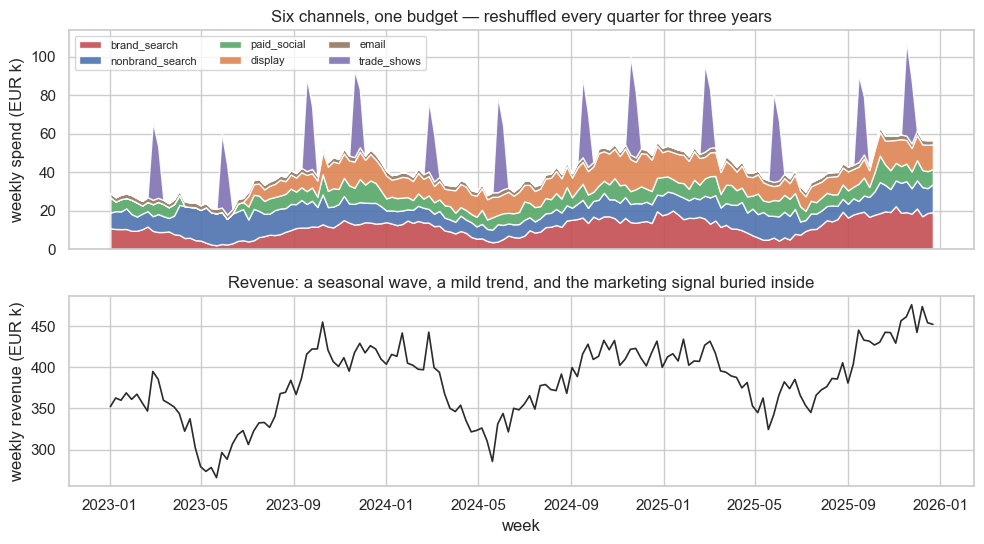

In [4]:
book = pd.DataFrame({
    "EUR/yr":       {c: mix[c].sum()/3 for c in CHANNELS},
    "share":        {c: mix[c].sum()/mix[CHANNELS].sum().sum() for c in CHANNELS},
    "EUR/wk (avg)": {c: mix[c].mean() for c in CHANNELS},
    "min wk":       {c: mix[c].min() for c in CHANNELS},
    "max wk":       {c: mix[c].max() for c in CHANNELS},
    "TRUE EUR/wk":  {c: truth[c].mean() for c in CHANNELS},
    "TRUE ROAS":    {c: truth[c].sum()/mix[c].sum() for c in CHANNELS},
})
print(book.assign(share=lambda d: (d.share*100).round(1)).round(2).to_string(
      float_format=lambda v: f"{v:,.2f}"))
print(f"\ntotal spend      EUR {mix[CHANNELS].sum().sum()/3:>12,.0f} / year")
print(f"total revenue    EUR {mix.revenue.sum()/3:>12,.0f} / year")
print(f"marketing's TRUE share of revenue: {truth.sum().sum()/mix.revenue.sum():.1%}")

# FIG 1 -- three years of budget, and the revenue it was supposed to move
fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True,
                         gridspec_kw={"height_ratios": [1.15, 1]})
colors = dict(zip(CHANNELS, ["#c44e52", "#4c72b0", "#55a868", "#dd8452", "#937860", "#8172b3"]))
axes[0].stackplot(mix.date, [mix[c]/1000 for c in CHANNELS],
                  labels=CHANNELS, colors=[colors[c] for c in CHANNELS], alpha=0.9)
axes[0].set_ylabel("weekly spend (EUR k)")
axes[0].set_title("Six channels, one budget — reshuffled every quarter for three years")
axes[0].legend(loc="upper left", ncol=3, fontsize=8)
axes[1].plot(mix.date, mix.revenue/1000, color="#2b2b2b", lw=1.2)
axes[1].set_ylabel("weekly revenue (EUR k)")
axes[1].set_xlabel("week")
axes[1].set_title("Revenue: a seasonal wave, a mild trend, and the marketing signal buried inside")
plt.tight_layout()

Two features of that top panel are worth naming before we do anything clever, because they decide what is knowable later.

- **The budget moves, a lot.** Non-brand search averaged **€12,149** a week in year 1, was cut to **€7,814** in year 2 to feed branded search, and recovered to **€11,191** in year 3. Branded search went the other way — €8,822 → €11,662 → €14,132. Paid social was dark for **10 weeks** during an agency handover. Retargeting did not exist for the first **26 weeks**. Trade shows are paid in **24 weeks out of 156** and nothing in the other 132. **Every one of those is a natural experiment the company ran without meaning to**, and they are the only reason a response curve is estimable at all.
- **One channel does not move.** Email is €2,308 a week, every week, for three years — the same newsletter to the same list. Hold that thought until §3; it has a punchline.

The bottom panel is what the CMO actually watches, and it is useless on its own: a strong Q4, a summer dip, and a slow climb. Marketing is **31.6 %** of it, and no amount of staring will tell you which 31.6 %.

## 2. Last-click is a ranking of who closed, not who caused

The dashboard the CFO read is built from the webshop's own click log. Every order carries a **touchpath** — the sequence of marketing contacts that preceded it — and the dashboard applies the industry default: **give 100 % of the order's revenue to the last touch before purchase.**

That rule is not wrong so much as it is answering a different question. It measures **who was standing closest to the till**. Let's rebuild the log and read the ranking it produces.

In [5]:
# ── a touchpath log: one row per order, the channels that touched it, the closer
CLOSER = {"brand_search": 0.36, "display": 0.16, "nonbrand_search": 0.13,
          "email": 0.05, "paid_social": 0.03, "trade_shows": 0.01, "(direct)": 0.26}
EXPOSE = {"paid_social": 0.24, "nonbrand_search": 0.20, "trade_shows": 0.18,
          "email": 0.15, "display": 0.14, "brand_search": 0.09}

rng = np.random.default_rng(101)
n_orders = int(round(mix.revenue.sum() / AOV))
last_touch = rng.choice(list(CLOSER), n_orders, p=list(CLOSER.values()))
n_earlier = np.clip(rng.poisson(1.5, n_orders), 0, 4)          # touches before the closer
earlier = rng.choice(list(EXPOSE), (n_orders, 4), p=list(EXPOSE.values()))
value = rng.lognormal(np.log(AOV) - 0.5*0.55**2, 0.55, n_orders)
value *= mix.revenue.sum() / value.sum()                       # tie the log to the P&L

first_touch = np.where(n_earlier > 0, earlier[:, 0], last_touch)
touched = {c: int(sum(((earlier[:, j] == c) & (n_earlier > j)).sum() for j in range(4))
                  + (last_touch == c).sum()) for c in CHANNELS}

log = pd.DataFrame({"order_value": value.round(2), "n_touches": n_earlier + 1,
                    "first_touch": first_touch, "last_touch": last_touch})
print(f"{n_orders:,} orders, EUR {value.sum():,.0f} of revenue over three years\n")
print(log.head(6).to_string(index=False))

75,541 orders, EUR 59,677,400 of revenue over three years

 order_value  n_touches     first_touch      last_touch
      652.52          2     trade_shows        (direct)
      484.34          5 nonbrand_search    brand_search
      528.57          1        (direct)        (direct)
     1099.02          5         display nonbrand_search
      276.09          2 nonbrand_search    brand_search
      788.58          2     paid_social        (direct)


                  spend (3y)  last-click €  LAST-CLICK ROAS  first-click ROAS  touched %  closed %  TRUE ROAS
brand_search    1,800,000.00 21,591,880.11            12.00              5.04      49.36     35.96       1.72
email             360,000.00  2,938,437.55             8.16             21.37      27.23      4.94       3.79
display         1,440,000.00  9,499,437.73             6.60              6.10      36.83     15.96       1.11
nonbrand_search 1,620,000.00  7,721,150.02             4.77              6.63      42.67     12.99       3.52
paid_social     1,080,000.00  1,850,743.76             1.71             10.70      38.68      3.14       3.75
trade_shows       900,000.00    590,034.51             0.66              9.43      27.64      0.99       3.39

'(direct)' -- no paid touch at all: EUR 15,485,716 (26% of orders) credited to nobody

last-click ranking : brand_search > email > display > nonbrand_search > paid_social > trade_shows
TRUE ROAS ranking  : email > paid_social > n

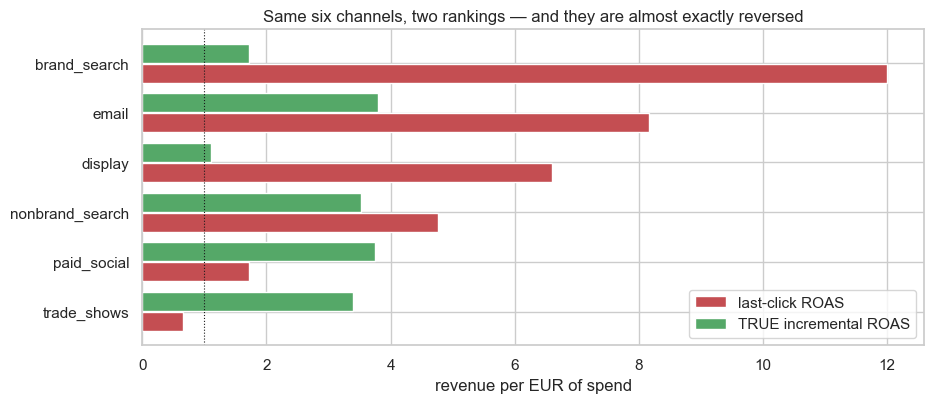

In [6]:
spend3 = {c: mix[c].sum() for c in CHANNELS}
attr = pd.DataFrame({
    "spend (3y)":    spend3,
    "last-click €":  {c: value[last_touch == c].sum() for c in CHANNELS},
    "LAST-CLICK ROAS": {c: value[last_touch == c].sum()/spend3[c] for c in CHANNELS},
    "first-click ROAS": {c: value[first_touch == c].sum()/spend3[c] for c in CHANNELS},
    "touched %":     {c: touched[c]/n_orders*100 for c in CHANNELS},
    "closed %":      {c: (last_touch == c).mean()*100 for c in CHANNELS},
    "TRUE ROAS":     {c: truth[c].sum()/spend3[c] for c in CHANNELS},
}).sort_values("LAST-CLICK ROAS", ascending=False)
print(attr.round(2).to_string(float_format=lambda v: f"{v:,.2f}"))
print(f"\n'(direct)' -- no paid touch at all: EUR {value[last_touch == '(direct)'].sum():,.0f} "
      f"({(last_touch == '(direct)').mean():.0%} of orders) credited to nobody")
print("\nlast-click ranking :", " > ".join(attr.index))
print("TRUE ROAS ranking  :", " > ".join(attr.sort_values('TRUE ROAS', ascending=False).index))

# FIG 2 -- the ranking the dashboard prints, next to the ranking that is true
order = list(attr.index)
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.barh(y + 0.20, attr["LAST-CLICK ROAS"], height=0.38, color="#c44e52", label="last-click ROAS")
ax.barh(y - 0.20, attr["TRUE ROAS"], height=0.38, color="#55a868", label="TRUE incremental ROAS")
ax.axvline(1.0, color="k", lw=0.8, ls=":")
ax.set_yticks(y, order)
ax.invert_yaxis()
ax.set_xlabel("revenue per EUR of spend")
ax.set_title("Same six channels, two rankings — and they are almost exactly reversed")
ax.legend()
plt.tight_layout()

Read the two bars for the channel at each end.

**Branded search: 12.00× reported, 1.72× real.** It closed **35.96 %** of all orders — of course it did. When a purchasing manager has decided to reorder toner, they type the company's name, click the ad that sits above the organic link, and buy. The click was real, the order was real, and the ad was almost entirely **unnecessary**: without it, most of those people scroll two centimetres to the free organic result. Last-click credits the closer.

**Trade shows: 0.66× reported, 3.39× real.** Fairs touched **27.64 %** of orders and closed **0.99 %**. Nobody signs a €4,000 supply contract at a booth; they take a card, and six weeks later somebody searches the company name — where **branded search collects the credit for the conversation the fair paid for**. On the dashboard, trade shows return 66 cents per euro and rank **last of six**. On the truth they rank **fourth of six**, ahead of both channels the CFO wants to fund.

Now name the failures precisely, because there are **two** and they need different fixes:

> ⚠️ **Failure 1 — the attribution convention.** Last click is an *accounting rule*, not a measurement. It gives 100 % of the credit to whoever was standing there at the end. Swap the rule and the answer changes completely: first-click makes email a **21.37×** channel and paid social **10.70×**, versus 8.16× and 1.71× on last click. Neither number is more true than the other; both are conventions applied to the same log. And **26 % of revenue arrives with no paid touch at all**, so a quarter of the business is invisible to every one of them. Better conventions — linear, time-decay, Markov, Shapley — redistribute the same fixed pie more cleverly. They still never ask what would have happened anyway.
>
> ⚠️ **Failure 2 — reverse causality.** This one survives *any* attribution rule, and it is A1's disease exactly: **branded-search spend rises when demand rises.** The bidding algorithm buys more clicks in the weeks more people search the company's name, which are the weeks the company was going to sell more regardless. So even a channel-level regression will see branded search and revenue moving together and want to call it causation. Fixing the attribution rule cannot help, because the problem is not *who got the credit* — it is that the spend and the outcome share a hidden cause.

Failure 1 is why we stop using the click log for budget decisions. Failure 2 is why the model in §3 is not enough either, and why §5 exists.

---

### ✋ Quick exercise (~2 min) — three orders, three attribution rules

Three orders arrive, each worth **€1,000**, with these touchpaths (in order):

| order | path |
|---|---|
| 1 | trade_shows → paid_social → brand_search |
| 2 | nonbrand_search → brand_search |
| 3 | email → brand_search |

Split each order's €1,000 under **last-click**, **first-click** and **linear** (equal shares to every touch), and total the credit per channel. Then answer the question that matters: under the rule the dashboard uses, what does the budget meeting decide about trade shows?

In [7]:
# ✍️ Your turn 👇
paths = [["trade_shows", "paid_social", "brand_search"],
         ["nonbrand_search", "brand_search"],
         ["email", "brand_search"]]
ORDER_VALUE = 1_000.0
# credit each path under last-click / first-click / linear, then sum per channel:

<details>
<summary>✅ <b>Solution</b></summary>

```python
paths = [["trade_shows", "paid_social", "brand_search"],
         ["nonbrand_search", "brand_search"],
         ["email", "brand_search"]]
ORDER_VALUE = 1_000.0

rules = {"last-click":  lambda p: {p[-1]: ORDER_VALUE},
         "first-click": lambda p: {p[0]: ORDER_VALUE},
         "linear":      lambda p: {c: ORDER_VALUE/len(p) for c in p}}
credit = pd.DataFrame(0.0, index=sorted({c for p in paths for c in p}), columns=list(rules))
for rule, fn in rules.items():
    for p in paths:
        for c, v in fn(p).items():
            credit.loc[c, rule] += v
print(credit.round(0).to_string())
```

Last-click hands branded search **€3,000 of €3,000** and everything else zero. First-click hands it **nothing at all**. Linear gives it €1,333, with €500 each to non-brand search and email and €333 each to paid social and trade shows. Same three orders, same three thousand euros, three completely different pictures — which is the tell that none of them is a measurement.

The budget-meeting answer: under last click, trade shows generated **€0** of revenue this quarter and will be cut. They are, in fact, the reason order 1 exists at all. Note also that branded search appears in *every* path — that is not evidence that it works, it is evidence that people who are about to buy from you tend to search for your name. A channel that appears everywhere is a channel that measures intent, and you cannot buy intent from yourself.
</details>

## 3. The MMM: adstock, saturation, and what 156 weeks can identify

Marketing-mix modelling throws the click log away. It uses only what a regulator, a cookie ban and an ad-blocker cannot take from you: **weekly aggregate spend per channel and weekly aggregate revenue**. Then it regresses one on the other — with two transforms in between, because raw spend is the wrong regressor twice over.

**Adstock** handles carryover. Geometric adstock with decay $\lambda$:

$$a_t = s_t + \lambda\, a_{t-1}, \qquad x_t = (1-\lambda)\, a_t$$

The $(1-\lambda)$ renormalisation keeps a *constant* €10 k/week mapping to a level of €10 k, so the saturation parameter stays in euros you can talk about. The decay's plain-English version is the **half-life**, $\ln(0.5)/\ln(\lambda)$ weeks.

**Saturation** handles diminishing returns. We use the Hill/Michaelis–Menten form:

$$f(x) = \frac{x}{x + h}$$

$h$ is the **half-saturation point**: the weekly (adstocked) spend at which the channel delivers half of its ceiling $\beta$. A channel's revenue contribution in week $t$ is then $\beta_c\, f_c(x_{c,t})$, and — this is the number the budget meeting actually needs — the **marginal** return of one more euro is the derivative:

$$\frac{\partial}{\partial s}\,\beta \frac{s}{s+h} \;=\; \frac{\beta h}{(s+h)^2}$$

Notice these two are different questions with different answers. A channel can have a wonderful *average* ROAS and a terrible *marginal* one — that is precisely what "saturated" means, and it is what the CFO's 12× cannot see even in principle.

      decay 0.15 (half-life 0.4 wk)  decay 0.50 (half-life 1.0 wk)  decay 0.80 (half-life 3.1 wk)
wk 0                              0                              0                              0
wk 1                              0                              0                              0
wk 2                         85,000                         50,000                         20,000
wk 3                         12,750                         25,000                         16,000
wk 4                          1,912                         12,500                         12,800
wk 5                            287                          6,250                         10,240
wk 6                             43                          3,125                          8,192
wk 7                              6                          1,562                          6,554

saturation — what one more EUR 1,000/week buys, by channel (planted truth):
channel           spend/wk  contribution 

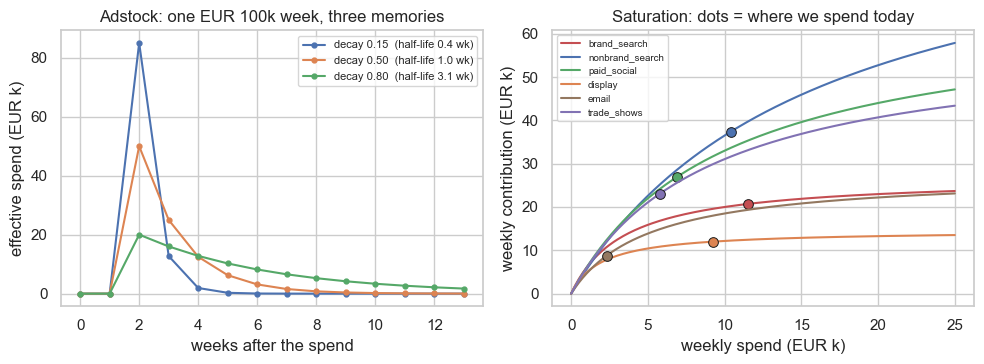

In [8]:
# what carryover looks like: one EUR 100k trade-show week, three decay rates
spike = np.zeros(14); spike[2] = 100_000
demo = pd.DataFrame({f"decay {d:.2f} (half-life {np.log(.5)/np.log(d):.1f} wk)": adstock(spike, d)
                     for d in (0.15, 0.50, 0.80)}, index=[f"wk {i}" for i in range(14)])
print(demo.iloc[:8].round(0).to_string(float_format=lambda v: f"{v:>9,.0f}"))

print("\nsaturation — what one more EUR 1,000/week buys, by channel (planted truth):")
print(f"{'channel':16s} {'spend/wk':>9} {'contribution':>13} {'avg ROAS':>9} {'MARGINAL ROAS':>14}")
for c in CHANNELS:
    p, s = CHANNEL_BOOK[c], mix[c].mean()
    print(f"{c:16s} {s:>9,.0f} {truth[c].mean():>13,.0f} {truth[c].mean()/s:>9.2f} "
          f"{p['beta']*p['half']/(s + p['half'])**2:>14.2f}")

# FIG 3 -- the two transforms, side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for d, col in zip((0.15, 0.50, 0.80), ["#4c72b0", "#dd8452", "#55a868"]):
    axes[0].plot(range(14), adstock(spike, d)/1000, "-o", ms=3.5, color=col,
                 label=f"decay {d:.2f}  (half-life {np.log(.5)/np.log(d):.1f} wk)")
axes[0].set_xlabel("weeks after the spend"); axes[0].set_ylabel("effective spend (EUR k)")
axes[0].set_title("Adstock: one EUR 100k week, three memories"); axes[0].legend(fontsize=8)

grid = np.linspace(0, 25_000, 200)
for c in CHANNELS:
    p = CHANNEL_BOOK[c]
    axes[1].plot(grid/1000, p["beta"]*saturate(grid, p["half"])/1000, color=colors[c], label=c)
    axes[1].plot(mix[c].mean()/1000, p["beta"]*saturate(mix[c].mean(), p["half"])/1000,
                 "o", color=colors[c], ms=7, mec="k", mew=0.7)
axes[1].set_xlabel("weekly spend (EUR k)"); axes[1].set_ylabel("weekly contribution (EUR k)")
axes[1].set_title("Saturation: dots = where we spend today"); axes[1].legend(fontsize=7)
plt.tight_layout()

The dots are the argument for the whole notebook. Branded search and display sit far out on the flat part of their curves — buying the same demand over and over. Non-brand search, paid social and trade shows sit on the steep part, where the next euro still does something. Nobody put them there on purpose; they got there because a dashboard said 12.00×.

---

### ✋ Quick exercise (~2 min) — adstock by hand

A trade show costs **€60,000**, paid in a single week, and nothing is spent in the nineteen weeks that follow. Using `adstock`, work out the effective spend across those twenty weeks for `decay = 0.80` (a fair) and `decay = 0.15` (an email blast).

Then answer both in words: what is each channel's **half-life** in weeks, and how many weeks does it take the fair's effective spend to fall below **5 %** of its peak?

In [9]:
# ✍️ Your turn 👇
show = np.zeros(20); show[0] = 60_000
# half_life = np.log(0.5) / np.log(decay)
# carried = adstock(show, decay)   -- for decay in (0.80, 0.15)

<details>
<summary>✅ <b>Solution</b></summary>

```python
show = np.zeros(20); show[0] = 60_000
for d in (0.80, 0.15):
    carried = adstock(show, d)
    below = int(np.argmax(carried < 0.05 * carried[0]))
    print(f"decay {d:.2f}  half-life {np.log(0.5)/np.log(d):>5.2f} wk   peak {carried[0]:>8,.0f}   "
          f"below 5% of peak in week {below}   20-week total {carried.sum():>8,.0f}")
```

At `decay = 0.80` the fair's €60,000 becomes **€12,000** of effective spend in the week itself and then decays by 20 % a week: **half-life 3.11 weeks**, and it does not fall below 5 % of its peak until week **14**. At `decay = 0.15` the €60,000 becomes **€51,000** immediately and is under 5 % by week **2**: half-life **0.37 weeks**.

That is the entire difference between a channel you evaluate weekly and a channel you must evaluate quarterly — and it is why a "cost per lead this week" dashboard structurally hates trade shows. Note also what the renormalisation does: it moves euros *between* weeks without creating any. The fast channel's twenty weeks sum to the full **€60,000**; the slow one's to **€59,308**, with the missing €692 still arriving after week 20.
</details>

### The model, and the controls that earn their keep

$$\text{revenue}_t \;=\; \underbrace{\alpha + \gamma\, t + \text{Fourier}_t + \delta\,\text{promo}_t + \pi\,\text{price}_t + \kappa\,\text{comp}_t}_{\text{baseline — what happens without this year's marketing}} \;+\; \sum_c \beta_c\, f_c\!\big(\text{adstock}(s_{c,t};\lambda_c)\big) \;+\; \varepsilon_t$$

The control list is A1 §3's, transplanted: every one of them exists to stop the regression handing a channel credit for something else's work.

| Control | The job it does |
|---|---|
| `sin1, cos1, sin2, cos2` | absorbs the annual seasonal wave (NB 11's Fourier pair). Without it, **every channel that spends more in Q4 gets credited with Christmas.** |
| `promo` | absorbs A1's flyer weeks — the display effect sells units at the same prices |
| `price_index` | A1's price rises moved volume; without this the model blames a channel for them |
| `competitor_index` | the rival's ad pressure, bought from a media monitor |
| `t` (trend) | the underlying 4 % growth, so a channel that ramped up over three years is not credited with it |

Three implementation choices that separate a working MMM from a broken one:

1. **Channel coefficients are constrained non-negative.** A channel cannot subtract revenue; if the data says it did, the data is noise. (`scipy.optimize.lsq_linear` with per-variable bounds.)
2. **The hyper-parameters $(\lambda_c, h_c)$ are searched, not assumed** — by coordinate descent over a grid, refitting the linear model inside every trial.
3. **The channel coefficients are penalised (ridge).** This is not decoration, and §3's second half is about why.

In [10]:
CONTROLS = ["const", "trend", "sin1", "cos1", "sin2", "cos2", "promo", "price", "competitor"]
NC = len(CONTROLS)
SCALE = {c: mix[c].mean() for c in CHANNELS}          # h is searched as a multiple of this


def control_matrix(d):
    t = d.week.to_numpy()
    return np.column_stack([
        np.ones(len(d)), t/52,
        np.sin(2*np.pi*t/52), np.cos(2*np.pi*t/52),
        np.sin(4*np.pi*t/52), np.cos(4*np.pi*t/52),
        d.promo.to_numpy(), d.price_index.to_numpy() - 1, d.competitor_index.to_numpy() - 1])


def design(d, params):
    '''Controls + one saturated, adstocked column per channel.'''
    return np.column_stack([control_matrix(d)] +
        [saturate(adstock(d[c].to_numpy(), params[c][0]), params[c][1]*SCALE[c]) for c in CHANNELS])


def fit_mmm(d, params, ridge):
    '''Non-negative channel coefficients + ridge penalty on them only.'''
    X, y = design(d, params), d.revenue.to_numpy()
    lo = np.concatenate([np.full(NC, -np.inf), np.zeros(len(CHANNELS))])
    hi = np.full(X.shape[1], np.inf)
    if ridge > 0:
        aug = np.zeros((len(CHANNELS), X.shape[1]))
        aug[:, NC:] = np.eye(len(CHANNELS)) * np.sqrt(ridge)
        A, b = np.vstack([X, aug]), np.concatenate([y, np.zeros(len(CHANNELS))])
    else:
        A, b = X, y
    coef = lsq_linear(A, b, bounds=(lo, hi)).x
    return coef, float(((y - X @ coef)**2).sum()), X


DECAY_GRID = np.round(np.arange(0.0, 0.90, 0.05), 2)
H_GRID = np.array([0.15, 0.22, 0.3, 0.45, 0.6, 0.8, 1.0, 1.3, 1.7, 2.2, 2.9, 3.8, 5.0, 6.5, 8.5])


def tune_hyper(d, ridge, passes=3):
    '''Coordinate descent over (decay, h) per channel; the linear fit is refitted inside.'''
    params = {c: (0.30, 1.0) for c in CHANNELS}
    for _ in range(passes):
        for c in CHANNELS:
            best, best_p = np.inf, params[c]
            for decay in DECAY_GRID:
                for k in H_GRID:
                    trial = dict(params); trial[c] = (float(decay), float(k))
                    _, ssr, _ = fit_mmm(d, trial, ridge)
                    if ssr < best:
                        best, best_p = ssr, (float(decay), float(k))
            params[c] = best_p
    return params

In [11]:
# ── choosing the ridge penalty. Two criteria, and they disagree.
#    (a) out-of-sample forecast error, expanding window, three 13-week folds
#    (b) does the model's implied BASELINE match what the business knows?
print(f"{'ridge':>6} {'out-of-sample RMSE':>20} {'implied baseline/wk':>21} {'marketing share':>17}")
for ridge in (0.0, 0.02, 0.05, 0.09, 0.15):
    sse = 0.0
    for cut in (104, 117, 130):
        tr = mix.iloc[:cut].reset_index(drop=True)
        p_tr = tune_hyper(tr, ridge)
        c_tr, _, _ = fit_mmm(tr, p_tr, ridge)
        Xf = design(mix, p_tr)                      # full history -> carryover is honest
        sse += float(((mix.revenue.to_numpy()[cut:cut+13] - Xf[cut:cut+13] @ c_tr)**2).sum())
    p_all = tune_hyper(mix, ridge)
    c_all, _, X_all = fit_mmm(mix, p_all, ridge)
    share = sum(c_all[NC+i]*X_all[:, NC+i].mean() for i in range(len(CHANNELS)))/mix.revenue.mean()
    print(f"{ridge:>6.2f} {np.sqrt(sse/39):>20,.0f} {c_all[0]:>21,.0f} {share:>17.1%}")
print(f"{'TRUTH':>6} {'':>20} {BASE_WK:>21,.0f} {truth.sum().sum()/mix.revenue.sum():>17.1%}")

 ridge   out-of-sample RMSE   implied baseline/wk   marketing share


  0.00                9,645               223,514             39.1%


  0.02                9,144               232,383             36.4%


  0.05                9,668               240,634             33.8%


  0.09                9,792               249,919             31.0%


  0.15               10,466               257,722             28.6%
 TRUTH                                    245,000             31.6%


Sit with that table, because it contains the single most misunderstood fact about marketing-mix models.

**The forecast prefers almost no penalty.** At `ridge = 0.02` the model predicts held-out quarters best (RMSE **€9,144** against €9,792 at 0.09). If you selected the model the way Module 5 taught you to — by out-of-sample error — you would ship it.

**And that model's decomposition is fiction.** At `ridge = 0.00` it puts the organic baseline at **€223,514 a week** and claims marketing drives **39.1 %** of revenue. Before the 2020 relaunch this webshop ran on the printed catalogue and four trade shows and turned over about €12.8 M a year — **€246 k a week** — on a smaller customer base than today. A model whose baseline is *below* that is telling you the business would be smaller without marketing than it was before it had any. That is not a hypothesis anyone in the company believes; it is the regression discovering that six always-on channels can each absorb a slice of the intercept and reduce the residual doing it.

> 🧭 **Prediction and attribution are different jobs.** A marketing-mix model is asked for a *decomposition*, and the data does not identify one: many splits between baseline and channels fit the weekly series almost equally well. Forecast accuracy cannot arbitrate between them, because all of them forecast fine. So you supply information from outside the regression — a penalty, an explicit prior, or (§5) an experiment. Bayesian MMM makes this honest by writing the priors down; Meta's Robyn does it with exactly the ridge penalty above. **Choosing `ridge = 0.09` costs 7 % of forecast accuracy and buys a baseline of €249,919/week against the €246 k the business knows.** We pay it, and we write down that we paid it.

That is still a judgement call standing where a measurement should be. Which is the argument for §5.

R2 = 0.9807   residual sd = EUR 6,472/week   n = 156 weeks, 15 linear + 12 non-linear parameters

                 decay  TRUE decay  half-sat    TRUE h      €/wk  TRUE €/wk  ratio  ROAS  TRUE ROAS
brand_search      0.00        0.20  5,192.31  3,500.00 30,182.25  19,882.53   1.52  2.62       1.72
nonbrand_search   0.00        0.35 13,500.00 16,000.00 25,235.54  36,518.43   0.69  2.43       3.52
paid_social       0.40        0.55  6,923.08 10,000.00 20,850.75  25,958.30   0.80  3.01       3.75
display           0.85        0.30  7,384.62  2,000.00 14,937.02  10,209.21   1.46  1.62       1.11
email             0.20        0.15  2,307.69  5,000.00  4,373.47   8,751.59   0.50  1.90       3.79
trade_shows       0.80        0.80  5,769.23  9,000.00 22,907.60  19,553.76   1.17  3.97       3.39

baseline: model 249,919/wk vs truth 245,000   |   marketing total: 118,487/wk vs truth 120,874


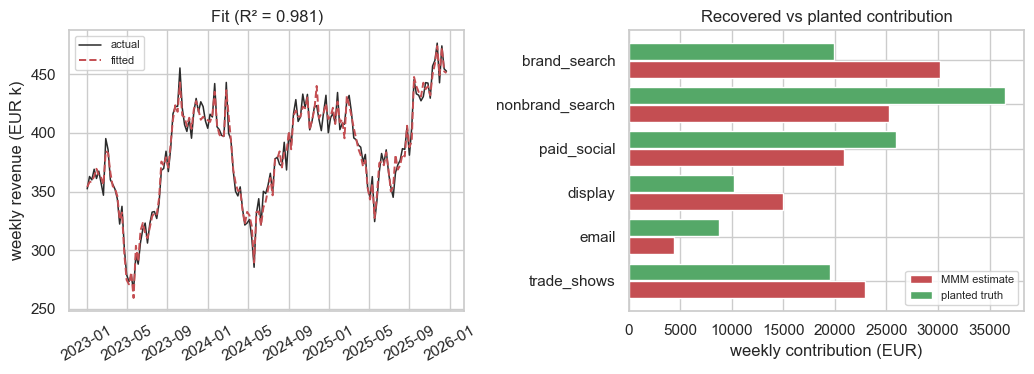

In [12]:
RIDGE = 0.09
PARAMS = tune_hyper(mix, RIDGE)
COEF, SSR, X = fit_mmm(mix, PARAMS, RIDGE)
BETA = {c: COEF[NC+i] for i, c in enumerate(CHANNELS)}
HALF = {c: PARAMS[c][1]*SCALE[c] for c in CHANNELS}
contrib_hat = pd.DataFrame({c: COEF[NC+i]*X[:, NC+i] for i, c in enumerate(CHANNELS)})

r2 = 1 - SSR/float(((mix.revenue - mix.revenue.mean())**2).sum())
print(f"R2 = {r2:.4f}   residual sd = EUR {np.sqrt(SSR/(WEEKS - X.shape[1])):,.0f}/week   "
      f"n = {WEEKS} weeks, {X.shape[1]} linear + {2*len(CHANNELS)} non-linear parameters\n")

recovered = pd.DataFrame({
    "decay":      {c: PARAMS[c][0] for c in CHANNELS},
    "TRUE decay": {c: CHANNEL_BOOK[c]["decay"] for c in CHANNELS},
    "half-sat":   HALF,
    "TRUE h":     {c: CHANNEL_BOOK[c]["half"] for c in CHANNELS},
    "€/wk":       contrib_hat.mean(),
    "TRUE €/wk":  truth.mean(),
    "ratio":      contrib_hat.mean()/truth.mean(),
    "ROAS":       {c: contrib_hat[c].mean()/mix[c].mean() for c in CHANNELS},
    "TRUE ROAS":  {c: truth[c].mean()/mix[c].mean() for c in CHANNELS},
})
print(recovered.round(2).to_string(float_format=lambda v: f"{v:,.2f}"))
print(f"\nbaseline: model {COEF[0]:,.0f}/wk vs truth {BASE_WK:,.0f}   |   "
      f"marketing total: {contrib_hat.mean().sum():,.0f}/wk vs truth {truth.mean().sum():,.0f}")

# FIG 4 -- does it fit, and does it decompose?
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
axes[0].plot(mix.date, mix.revenue/1000, color="#2b2b2b", lw=1.1, label="actual")
axes[0].plot(mix.date, (X @ COEF)/1000, color="#c44e52", lw=1.4, ls="--", label="fitted")
axes[0].set_ylabel("weekly revenue (EUR k)"); axes[0].set_title(f"Fit (R² = {r2:.3f})")
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", labelrotation=30)

yy = np.arange(len(CHANNELS))
axes[1].barh(yy + 0.20, [contrib_hat[c].mean() for c in CHANNELS], 0.38,
             color="#c44e52", label="MMM estimate")
axes[1].barh(yy - 0.20, [truth[c].mean() for c in CHANNELS], 0.38,
             color="#55a868", label="planted truth")
axes[1].set_yticks(yy, CHANNELS); axes[1].invert_yaxis()
axes[1].set_xlabel("weekly contribution (EUR)")
axes[1].set_title("Recovered vs planted contribution"); axes[1].legend(fontsize=8)
plt.tight_layout()

An honest scorecard, because the point of god mode is to grade the method rather than admire it:

- **The total is right.** The model puts marketing at **€118,487/week** against a planted **€120,874**, and the baseline at **€249,919** against **€245,000**. The split between "the business" and "the marketing" — the hardest number in the whole discipline — is within 2 %.
- **The two channels the model gets wrong are exactly the two we rigged.** **Branded search comes out at €30,182/week against a true €19,883 — a 1.5× overstatement** — and display at €14,937 against €10,209 (1.5×). These are the two whose spend chases demand. Of the rest, trade shows land at 1.17× of truth and paid social at 0.80×; non-brand search is the honest miss at 0.69×, understated because the ridge penalty bites hardest on the largest coefficient. §2's Failure 2 does not go away when you switch from click logs to regression; it just gets quieter. It is now a 1.5× error instead of a 7× one.
- **Email is a fabrication.** €4,373/week against a true €8,752 — off by half, and we are about to see that the model has no business quoting a number for it at all.
- **The hyper-parameters are much worse than the contributions.** Trade shows' decay is recovered at 0.80 against a true 0.80, but display's comes out at 0.85 against 0.30, and branded search's at 0.00 against 0.20. Do not read a fitted half-life as a fact about the world; several $(\lambda, h)$ pairs fit nearly identically (Stretch C makes that flatness visible). **The contributions and the marginal returns are the identified quantities. The hyper-parameters are scaffolding.**

### 🔮 Predict the output

We refit the whole model with carryover switched **off** — every channel's decay forced to zero, so this week's spend can only affect this week's revenue.

```python
params_nocarry = {c: (0.0, PARAMS[c][1]) for c in CHANNELS}
```

Commit before running. Which channel's estimated contribution **collapses**, and why? (Hint: look back at FIG 1's top panel and ask which channel spends nothing at all in 132 weeks out of 156.)

In [13]:
# Predict first, then run.
params_nocarry = {c: (0.0, PARAMS[c][1]) for c in CHANNELS}
coef_nc, ssr_nc, X_nc = fit_mmm(mix, params_nocarry, RIDGE)
print(f"R2 with carryover {r2:.4f}   without {1 - ssr_nc/float(((mix.revenue-mix.revenue.mean())**2).sum()):.4f}\n")
print(f"{'channel':16s} {'with adstock':>13} {'no adstock':>12} {'true decay':>11}")
for i, c in enumerate(CHANNELS):
    print(f"{c:16s} {contrib_hat[c].mean():>13,.0f} {coef_nc[NC+i]*X_nc[:, NC+i].mean():>12,.0f} "
          f"{CHANNEL_BOOK[c]['decay']:>11.2f}")

R2 with carryover 0.9807   without 0.9446

channel           with adstock   no adstock  true decay
brand_search            30,182       60,248        0.20
nonbrand_search         25,236       27,553        0.35
paid_social             20,851       18,671        0.55
display                 14,937       17,445        0.30
email                    4,373       10,275        0.15
trade_shows             22,908        2,462        0.80


<details>
<summary>💡 <b>Answer</b></summary>

**Trade shows collapse from €22,908 to €2,462 a week — a factor of nine.** Fairs are paid in 24 weeks out of 156 and nothing in the other 132. Without carryover the model is asked whether revenue spikes in the two weeks the invoice lands, and of course it doesn't: the booth conversation becomes an order in April. With no mechanism to move the effect forward in time, the only coefficient that fits is ≈0, and a channel worth €19,554 a week becomes a rounding error.

Branded search moves the other way — **up** to €60,248 — because with the carryover gone the model reaches for whatever regressor most closely tracks *this week's* demand, and branded search's spend is built from this week's demand. R² falls from 0.981 to 0.945.

The business lesson is bigger than the parameter: **any measurement window shorter than a channel's memory will report that the channel does not work.** Weekly ROAS dashboards, 7-day attribution windows and "cost per lead this month" all quietly implement `decay = 0` and then defund whatever is slow. Events, sponsorships, PR and brand campaigns are slow.
</details>

### Does it predict weeks it has never seen? And what can it not identify?

R² on the data you fitted is not evidence. Refit on the first 130 weeks, forecast the last 26 — and score against two baselines worth beating: **seasonal-naive** (this week last year) and the flat mean.

In [14]:
CUT = 130
p_train = tune_hyper(mix.iloc[:CUT].reset_index(drop=True), RIDGE)
c_train, _, _ = fit_mmm(mix.iloc[:CUT].reset_index(drop=True), p_train, RIDGE)
pred = design(mix, p_train)[CUT:] @ c_train          # adstock built on the full history
act = mix.revenue.to_numpy()[CUT:]

mape = lambda p: float(np.mean(np.abs(p - act)/act))
print(f"MMM, fitted on weeks 0-{CUT-1}      MAPE {mape(pred):>7.2%}")
print(f"seasonal naive (same week -1 yr)   MAPE {mape(mix.revenue.to_numpy()[CUT-52:WEEKS-52]):>7.2%}")
print(f"flat mean of the training window   MAPE {mape(np.full(len(act), mix.revenue[:CUT].mean())):>7.2%}")

print("\nhow much does a channel's estimate move when 6 months are withheld?")
X_tr = design(mix.iloc[:CUT].reset_index(drop=True), p_train)
for i, c in enumerate(CHANNELS):
    full, part = contrib_hat[c].mean(), c_train[NC+i]*X_tr[:, NC+i].mean()
    print(f"  {c:16s} full {full:>8,.0f}   train-only {part:>8,.0f}   ({part/full - 1:+.0%})")

MMM, fitted on weeks 0-129      MAPE   1.39%
seasonal naive (same week -1 yr)   MAPE   5.05%
flat mean of the training window   MAPE  10.78%

how much does a channel's estimate move when 6 months are withheld?
  brand_search     full   30,182   train-only   30,207   (+0%)
  nonbrand_search  full   25,236   train-only   24,275   (-4%)
  paid_social      full   20,851   train-only   16,917   (-19%)
  display          full   14,937   train-only   14,432   (-3%)
  email            full    4,373   train-only    2,687   (-39%)
  trade_shows      full   22,908   train-only   21,711   (-5%)


In [15]:
# ── identification, three ways ──────────────────────────────────────────────
# (1) block bootstrap (13-week blocks: weekly data is autocorrelated, so
#     resampling single weeks would understate the uncertainty)
rb = np.random.default_rng(3)
boot = []
for _ in range(300):
    idx = np.concatenate([np.arange(s, s+13) for s in rb.integers(0, WEEKS-13, 12)])
    lo = np.concatenate([np.full(NC, -np.inf), np.zeros(len(CHANNELS))])
    aug = np.zeros((len(CHANNELS), X.shape[1])); aug[:, NC:] = np.eye(len(CHANNELS))*np.sqrt(RIDGE)
    b = lsq_linear(np.vstack([X[idx], aug]),
                   np.concatenate([mix.revenue.to_numpy()[idx], np.zeros(len(CHANNELS))]),
                   bounds=(lo, np.full(X.shape[1], np.inf))).x
    boot.append([b[NC+i] for i in range(len(CHANNELS))])
BOOT = np.array(boot)

# (2) variance inflation: how collinear is each regressor with all the others?
def vif(Xm, j):
    others = np.delete(Xm, j, axis=1)
    resid = Xm[:, j] - others @ np.linalg.lstsq(others, Xm[:, j], rcond=None)[0]
    return 1/max(1e-12, 1 - (1 - (resid**2).sum()/((Xm[:, j] - Xm[:, j].mean())**2).sum()))

print(f"{'channel':16s} {'€/wk':>9} {'95% CI (block bootstrap)':>28} {'width/est':>10} {'VIF':>7} {'spend CV':>9}")
for i, c in enumerate(CHANNELS):
    lo_, hi_ = np.percentile(BOOT[:, i]*X[:, NC+i].mean(), [2.5, 97.5])
    pt = contrib_hat[c].mean()
    print(f"{c:16s} {pt:>9,.0f}   [{lo_:>9,.0f}, {hi_:>9,.0f}] {(hi_-lo_)/pt:>10.1f}x "
          f"{vif(X, NC+i):>7.1f} {mix[c].std()/mix[c].mean():>9.2f}")

# (3) what if the CMO had done the normal thing and moved every channel together?
sync = mix.copy()
idx_season = 1 + 0.45*((mix.week % 52).between(40, 51)).to_numpy() + 0.15*np.sin(2*np.pi*mix.week/52)
rs = np.random.default_rng(9)
for c in CHANNELS:
    s = idx_season * np.exp(rs.normal(0, 0.06, WEEKS))
    sync[c] = s * mix[c].sum()/s.sum()
X_sync = design(sync, PARAMS)
print("\nVIF if every channel had followed the SAME seasonal budget curve:")
print("  " + "  ".join(f"{c.split('_')[0]} {vif(X_sync, NC+i):.0f}" for i, c in enumerate(CHANNELS)))

channel               €/wk     95% CI (block bootstrap)  width/est     VIF  spend CV
brand_search        30,182   [   16,939,    41,558]        0.8x    17.2      0.42
nonbrand_search     25,236   [   16,290,    30,479]        0.6x     1.8      0.30
paid_social         20,851   [    9,834,    27,162]        0.8x     2.8      0.36
display             14,937   [    6,726,    19,235]        0.8x     4.3      0.53
email                4,373   [        0,    10,266]        2.3x     1.1      0.06
trade_shows         22,908   [   19,064,    26,149]        0.3x     1.3      2.42

VIF if every channel had followed the SAME seasonal budget curve:
  brand 6  nonbrand 6  paid 10  display 58  email 9  trade 73


Three limits, three numbers, and none of them is fixable by a better estimator.

**1 — A channel whose spend does not vary cannot be measured.** Email's spend has a coefficient of variation of **0.06**: the same newsletter, the same €2,300, 156 times. Its bootstrap interval is **[€0, €10,266] a week against a point estimate of €4,373** — 2.3 times as wide as the estimate, and it touches zero. The model is not being coy; there is genuinely no evidence in this dataset about what email does, because the company never ran a week without it. The correct output for email is not a number, it is **"unmeasured — go and vary it."**

**2 — A channel whose spend chases demand cannot be separated from demand.** Branded search's VIF is **17.2**: it is largely predictable from the seasonal terms and the trend, precisely because auto-bidding follows the same demand the Fourier pair is modelling. What is left over to identify $\beta$ with is thin, and what little there is still carries the unlogged demand shock. Hence the 1.5× overstatement, delivered with a straight face.

**3 — Channels that move together are one channel.** Our CMO reshuffled quarterly and killed campaigns for weeks at a time, so the other five columns are near-independent (VIFs of 1.1–4.3). Had they done the normal thing and scaled everything to the same seasonal plan, the VIFs would be **display 58, trade shows 73, paid social 10** — the model would be trying to split a single "marketing" variable into six, and would return whatever the noise suggested. **An erratic budget history is an asset on this one dimension**, which is worth saying out loud to the person who wants a stable annual plan.

> 📏 **Humility is structural here, not a personality trait.** We have **156 rows**. We are estimating 15 linear coefficients plus 12 non-linear ones, and the quantity we care about — the split between baseline and marketing — is the one the data speaks to least. The backtest is genuinely good (MAPE **1.39 %** against seasonal-naive's **5.05 %**), and the six-month holdout moves paid social's estimate by **−19 %** and email's by **−39 %**. That is the honest resolution of this instrument: **decision-grade, not decimal-grade.**

## 4. From coefficients to a budget

The CMO does not want contributions. They want six numbers that add to €2.4 M. The bridge is one idea from first-year microeconomics, and it is the only thing anyone needs to remember from this notebook:

> 🧭 **Equalise marginal returns.** If the last euro in trade shows returns €2.37 and the last euro in branded search returns €0.85, move a euro. Keep moving until the *marginal* return is the same everywhere. At that point no reshuffle can gain anything — and the mix will be nothing like the mix that maximises *average* ROAS.

Average and marginal ROAS answer different questions. **Average** asks "was this channel worth having?" — a question about the past, and mostly rhetorical. **Marginal** asks "should the next euro go here?" — the only question a budget meeting is actually allowed to answer.

In [16]:
def curve_hat(c, s):        # fitted weekly contribution at a steady weekly spend s
    return BETA[c] * s/(s + HALF[c])

def mroas_hat(c, s):        # fitted marginal revenue per extra EUR/week
    return BETA[c] * HALF[c]/(s + HALF[c])**2

def curve_true(c, s):       # god mode -- for grading the recommendation later
    p = CHANNEL_BOOK[c]
    return p["beta"] * s/(s + p["half"])

now = {c: mix[c].mean() for c in CHANNELS}
marg = pd.DataFrame({
    "EUR/wk now":   now,
    "avg ROAS":     {c: curve_hat(c, now[c])/now[c] for c in CHANNELS},
    "MARGINAL ROAS": {c: mroas_hat(c, now[c]) for c in CHANNELS},
    "marginal €profit": {c: mroas_hat(c, now[c])*GROSS_MARGIN for c in CHANNELS},
    "TRUE marginal": {c: (CHANNEL_BOOK[c]["beta"]*CHANNEL_BOOK[c]["half"]
                          / (now[c] + CHANNEL_BOOK[c]["half"])**2) for c in CHANNELS},
}).sort_values("MARGINAL ROAS", ascending=False)
print(marg.round(2).to_string(float_format=lambda v: f"{v:,.2f}"))
print("\nthe budget meeting's ranking (marginal):", " > ".join(marg.index))
print("last-click's ranking (§2)               :", " > ".join(attr.index))

                 EUR/wk now  avg ROAS  MARGINAL ROAS  marginal €profit  TRUE marginal
trade_shows        5,769.23      4.75           2.37              0.85           2.43
paid_social        6,923.08      3.15           1.57              0.57           2.30
nonbrand_search   10,384.62      2.48           1.40              0.51           2.18
email              2,307.69      1.90           0.95              0.34           2.60
brand_search      11,538.46      2.74           0.85              0.31           0.42
display            9,230.77      1.88           0.84              0.30           0.23

the budget meeting's ranking (marginal): trade_shows > paid_social > nonbrand_search > email > brand_search > display
last-click's ranking (§2)               : brand_search > email > display > nonbrand_search > paid_social > trade_shows


---

### ✋ Quick exercise (~2 min) — should the next €2,000 go into non-brand search?

Non-brand search currently runs at **€10,385 a week**. Using the fitted `BETA["nonbrand_search"]` and `HALF["nonbrand_search"]`:

1. What is its contribution now, and what would it be at €12,385 a week?
2. What is the **average** revenue per euro of that extra €2,000 — and how does it compare with `mroas_hat` evaluated at today's spend?
3. Trade shows' marginal return is **2.37**. At 36 % gross margin, does the €2,000 belong in non-brand search, in trade shows, or in neither?

In [17]:
# ✍️ Your turn 👇
c = "nonbrand_search"
s_now, step = now[c], 2_000.0
# contribution now / after; the average return of the step; mroas_hat at s_now:

<details>
<summary>✅ <b>Solution</b></summary>

```python
c, step = "nonbrand_search", 2_000.0
s_now = now[c]
gain = curve_hat(c, s_now + step) - curve_hat(c, s_now)
print(f"contribution  {curve_hat(c, s_now):>9,.0f} -> {curve_hat(c, s_now + step):>9,.0f} EUR/wk")
print(f"average return of the step  {gain/step:.2f} EUR revenue per EUR")
print(f"marginal at today's spend   {mroas_hat(c, s_now):.2f}   at the new spend {mroas_hat(c, s_now + step):.2f}")
print(f"trade shows marginal        {mroas_hat('trade_shows', now['trade_shows']):.2f}")
for label, r in [("non-brand step", gain/step), ("trade shows", mroas_hat('trade_shows', now['trade_shows']))]:
    print(f"  {label:16s} gross profit per EUR spent: {r*GROSS_MARGIN:.2f}")
```

Non-brand search goes from **€25,799 to €28,390** a week — the €2,000 buys **€1.30 of revenue per euro**, below the €1.40 that `mroas_hat` reports at today's spend and above the €1.20 it reports at the new one, because the curve bends *while you walk up it*. (That gap is the whole reason §4 optimises over the curve instead of ranking the derivatives once and stopping.)

Trade shows return **€2.37** for the same euro, so the money goes there — and it keeps going there until trade shows' marginal falls to meet non-brand's. That is the equalisation rule doing its work.

The third answer is the uncomfortable one. At 36 % gross margin, €1.30 of revenue is **€0.47 of gross profit**, and even trade shows' €2.37 is only **€0.85**. On the model's own numbers *no* channel's next euro pays for itself in margin — which is a statement about the **size** of the €2.4 M, not its split. Park it: §4's brief is the allocation, 🧪 Exercise 4 puts a number on the total, and §6 says why that is a harder question than it looks.
</details>

### Guardrails, before anyone writes a number on a slide

A1 §5 built three of these for a price. They transfer intact to a budget, and they are what turn six optimiser outputs into a recommendation a grown-up can defend.

**Guardrail 1 — bootstrap the curves.** The response curve is a point estimate of two parameters; quote it alone and you are pretending a regression is a measurement. We propagate §3's block bootstrap through the whole curve.

**Guardrail 2 — never leave the spend range you have actually run.** A response curve is an extrapolation the moment it leaves the data. We bound each channel to the range of **sustained (13-week average) spend the company has actually operated**, 5th to 95th percentile. This is the guardrail that does the most work below — and email gets a stricter version of it: its 13-week average has never left a €120 band in three years, so rather than pretend there is a range to optimise over, we **freeze it at today's €2,308**. The model already told us it cannot measure email; the guardrail makes it impossible to act on the number anyway.

**Guardrail 3 — the optimum is flat.** Near the peak the gradient is zero by construction, so "€8,358" and "€9,000" are the same recommendation. Report ranges, and spend the argument on the channels that are far from optimal rather than on the third decimal of the ones that are close.

channel           now €/wk     sustained range actually run
brand_search        11,538   [   4,487,   18,136]
nonbrand_search     10,385   [   6,992,   14,762]
paid_social          6,923   [   2,361,    9,078]
display              9,231   [       0,   15,549]
email                2,308   [   2,308,    2,308]  <- frozen: unmeasurable (§3)
trade_shows          5,769   [   2,335,   11,892]


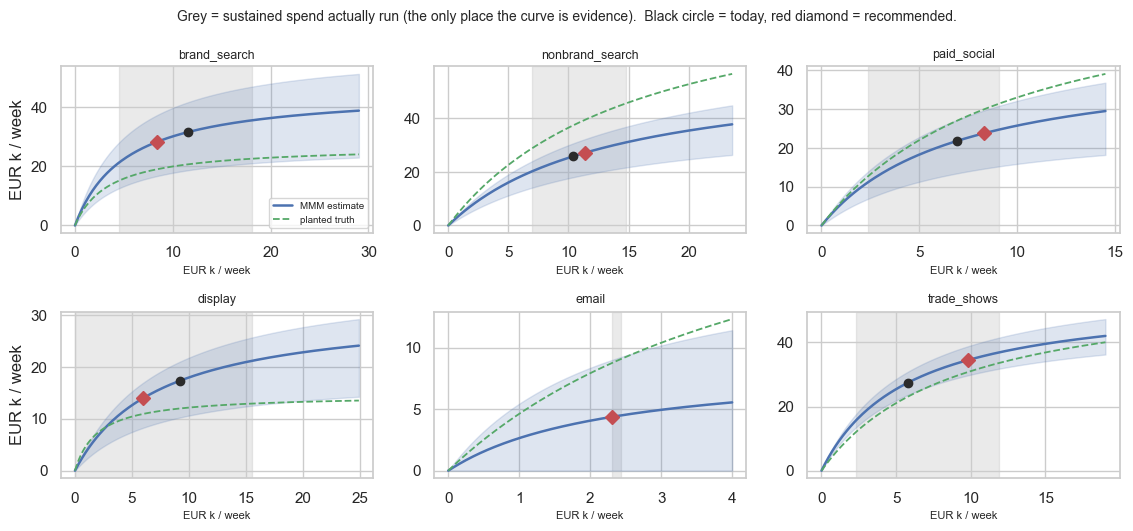

In [18]:
# ── bootstrap band + observed-support band per channel
BAND = {}
for c in CHANNELS:
    ma = mix[c].rolling(13).mean().dropna()
    BAND[c] = (float(np.percentile(ma, 5)), float(np.percentile(ma, 95)))
BAND["email"] = (now["email"], now["email"])      # unmeasured -> frozen, by policy

print(f"{'channel':16s} {'now €/wk':>9} {'sustained range actually run':>32}")
for c in CHANNELS:
    tag = "  <- frozen: unmeasurable (§3)" if c == "email" else ""
    print(f"{c:16s} {now[c]:>9,.0f}   [{BAND[c][0]:>8,.0f}, {BAND[c][1]:>8,.0f}]{tag}")

WEEKLY = BUDGET/52


def optimise_budget(bounds, curve):
    lo = np.array([bounds[c][0] for c in CHANNELS])
    hi = np.array([bounds[c][1] for c in CHANNELS])
    x0 = np.clip(np.array([now[c] for c in CHANNELS])*WEEKLY/sum(now.values()), lo, hi)
    res = minimize(lambda x: -sum(curve(c, xi) for c, xi in zip(CHANNELS, x)), x0,
                   method="SLSQP", bounds=list(zip(lo, hi)),
                   constraints=[{"type": "eq", "fun": lambda x: x.sum() - WEEKLY}],
                   options={"maxiter": 500, "ftol": 1e-6})
    return dict(zip(CHANNELS, res.x))


plan = optimise_budget(BAND, curve_hat)

# FIG 5 -- six response curves, with the evidence they rest on
fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.4), sharex=False)
for ax, c in zip(axes.ravel(), CHANNELS):
    hi = max(BAND[c][1]*1.6, now[c]*1.6, plan[c]*1.3, 4_000)
    g = np.linspace(0, hi, 160)
    band = np.percentile(np.array([b*g/(g + HALF[c]) for b in BOOT[:, CHANNELS.index(c)]]),
                         [5, 95], axis=0)
    ax.fill_between(g/1000, band[0]/1000, band[1]/1000, color="#4c72b0", alpha=0.18)
    ax.plot(g/1000, curve_hat(c, g)/1000, color="#4c72b0", lw=1.8, label="MMM estimate")
    ax.plot(g/1000, curve_true(c, g)/1000, color="#55a868", lw=1.3, ls="--", label="planted truth")
    ax.axvspan(BAND[c][0]/1000, max(BAND[c][1], BAND[c][0]+120)/1000,
               color="#bbbbbb", alpha=0.30, zorder=0)
    ax.plot(now[c]/1000, curve_hat(c, now[c])/1000, "o", color="#2b2b2b", ms=6)
    ax.plot(plan[c]/1000, curve_hat(c, plan[c])/1000, "D", color="#c44e52", ms=7)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel("EUR k / week", fontsize=8)
axes[0, 0].set_ylabel("EUR k / week"); axes[1, 0].set_ylabel("EUR k / week")
axes[0, 0].legend(fontsize=7, loc="lower right")
fig.suptitle("Grey = sustained spend actually run (the only place the curve is evidence).  "
             "Black circle = today, red diamond = recommended.", fontsize=10)
plt.tight_layout()

In [19]:
free_plan = optimise_budget({c: (0.0, 1e9) for c in CHANNELS}, curve_hat)
lastclick_plan = {}                       # the CFO's plan: fund the last-click winners
left = WEEKLY
for c in list(attr.index)[:-1]:
    floor_rest = sum(BAND[x][0] for x in list(attr.index)[list(attr.index).index(c)+1:])
    lastclick_plan[c] = float(np.clip(left - floor_rest, *BAND[c]))
    left -= lastclick_plan[c]
lastclick_plan[list(attr.index)[-1]] = left

print(f"{'channel':16s} {'now €/yr':>11} {'PLAN €/yr':>11} {'change':>11}   {'marginal now':>12} {'at plan':>8}")
for c in CHANNELS:
    print(f"{c:16s} {now[c]*52:>11,.0f} {plan[c]*52:>11,.0f} {(plan[c]-now[c])*52:>+11,.0f}   "
          f"{mroas_hat(c, now[c]):>12.2f} {mroas_hat(c, plan[c]):>8.2f}")
print(f"{'TOTAL':16s} {sum(now.values())*52:>11,.0f} {sum(plan.values())*52:>11,.0f} "
      f"{(sum(plan.values())-sum(now.values()))*52:>+11,.0f}")

print(f"\n{'plan':34s} {'MODEL says €/yr':>17} {'TRUTH says €/yr':>17} {'vs last year':>15}")
base_hat = sum(curve_hat(c, now[c]) for c in CHANNELS)*52
base_true = sum(curve_true(c, now[c]) for c in CHANNELS)*52
for name, alloc in [("same split as last year", now), ("CFO: follow last-click ROAS", lastclick_plan),
                    ("MMM optimum, guardrails on", plan), ("MMM optimum, guardrails off", free_plan)]:
    mh = sum(curve_hat(c, alloc[c]) for c in CHANNELS)*52
    mt = sum(curve_true(c, alloc[c]) for c in CHANNELS)*52
    print(f"{name:34s} {mh:>17,.0f} {mt:>17,.0f} {mt - base_true:>+15,.0f}")

channel             now €/yr   PLAN €/yr      change   marginal now  at plan
brand_search         600,000     434,594    -165,406           0.85     1.30
nonbrand_search      540,000     590,367     +50,367           1.40     1.30
paid_social          360,000     432,953     +72,953           1.57     1.30
display              480,000     310,103    -169,897           0.84     1.30
email                120,000     120,000          +0           0.95     0.95
trade_shows          300,000     511,984    +211,984           2.37     1.30
TOTAL              2,400,000   2,400,000          +0

plan                                 MODEL says €/yr   TRUTH says €/yr    vs last year
same split as last year                    6,673,835         6,701,628              +0
CFO: follow last-click ROAS                5,595,794         5,085,205      -1,616,423
MMM optimum, guardrails on                 6,867,325         7,224,133        +522,505
MMM optimum, guardrails off                6,873,478       

The table is the deliverable, and it says three *kinds* of thing, not six numbers:

1. **Take €165,406 out of branded search and €169,897 out of display.** Both are far past the knee of their curves; both are buying demand that already exists. This is the recommendation the CFO will fight, and §5 exists to win that fight.
2. **Put €211,984 into trade shows, €72,953 into paid social, €50,367 into non-brand search.** All three sit on the steep part of the curve, and trade shows — the channel last click wanted to cut for returning 66 cents on the euro — absorbs the largest single increase in the plan.
3. **Freeze email and go and test it.** Not because it is bad; because the €4,373/week estimate has a bootstrap interval that includes zero. A recommendation you cannot defend is not a recommendation. The deliverable for email is a **test**: run the newsletter at two sends a week in half the list for a quarter, and stop guessing.

And the numbers under it, in the order a CMO should hear them:

- The plan **reshuffles €335,303** — 14 % of the budget — and the model expects **+€193,490 of revenue a year for zero extra spend**.
- **God mode says the plan is actually worth +€522,505**, nearly three times what the model promised. That is not luck: the model still overstates branded search and display by ~1.5× (§3), so it *under*-cuts them, and reality rewards the cut harder than the model dared to hope. A biased model can still produce a good decision when the bias points the same way as the action.
- **The CFO's last-click plan destroys €1,616,423 of revenue a year.** Funding the dashboard's ranking from the top down takes branded search to €943,080 and display to €729,148, and leaves non-brand search, paid social and trade shows on their floors. That is the €-value of §2's lesson, and it is the number to open the meeting with.
- **The guardrails cost nothing here; they gain.** Guardrails-off is worth €7,177,530 in truth terms against the guarded plan's **€7,224,133** — the constrained plan is *better* in reality, because the guardrails stopped the model acting on its own worst estimates. And Guardrail 3's flatness is visible in the last two columns of the first table: the plan equalises the marginal returns of every unconstrained channel at **€1.30**, which is exactly the condition that says no further reshuffle can help.

> ⚠️ **Never quote the six numbers to three significant figures.** The optimum is flat, the curves are bootstrapped, and two channels sit at a guardrail rather than at an optimum. The defensible sentence is *"shift about a seventh of the budget out of the two harvesting channels into events and upper-funnel search, freeze email, and buy a measurement for branded search"* — and then the six numbers, as an illustration of that sentence rather than as the sentence itself.

## 5. The honest fix: buy the answer with a geo holdout

Everything in §4 rests on a regression that told us, in §3, that it cannot cleanly separate branded search from the demand it follows. We are about to ask the CFO to cut €165 k from their favourite channel on that basis. There is a better instrument, and it is A2's instrument: **stop reasoning about the counterfactual and go and create one.**

The design is a **geo holdout**. The webshop's customers cluster into 24 sales regions. Switch branded search **off** in a random half of them, leave it on in the other half, and compare. Randomisation does to region-level confounders exactly what A4 §3's coin flip did to customer-level ones: it kills the selection term by construction. Demand shocks, seasonality, price changes and the competitor's campaign hit both groups; the only systematic difference is the thing we switched.

A2's first rule applies before anything else is discussed: **can this test resolve the decision?** Branded search's true contribution is about 5 % of revenue, so an instrument with a minimum detectable effect of 6 % is a waste of a quarter. For a two-group comparison of region-level ratios,

$$\text{MDE} = (z_{\alpha/2} + z_{\beta})\, \sigma_{\text{ratio}} \sqrt{\tfrac{1}{n_t} + \tfrac{1}{n_c}}, \qquad \sigma_{\text{ratio}} = \sigma_{\text{weekly}}\sqrt{\tfrac{2}{T}}$$

where we measure each region's *post/pre revenue ratio* — the pre-period normalisation is CUPED's trick (A2 §4) in geographic clothing, and it is what makes a 24-region test viable at all.

In [20]:
N_REGIONS, SD_WEEKLY = 24, 0.08     # regional weekly revenue wobbles ~8 % around its own mean


def mde_geo(n_treat, n_ctrl, weeks, sd_weekly=SD_WEEKLY, alpha=0.05, power=0.80):
    '''Smallest detectable % change in regional revenue, as a fraction.'''
    z = stats.norm.ppf(1 - alpha/2) + stats.norm.ppf(power)
    return z * sd_weekly*np.sqrt(2/weeks) * np.sqrt(1/n_treat + 1/n_ctrl)


brand_share = truth["brand_search"].mean()/mix.revenue.mean()
print(f"branded search is {brand_share:.2%} of revenue -- that is the effect to resolve\n")
print(f"{'holdout regions':>16} {'weeks':>7} {'MDE':>8}   verdict")
for n_t, wks in [(4, 8), (3, 13), (12, 8), (6, 13), (12, 13), (12, 26), (12, 39)]:
    m = mde_geo(n_t, N_REGIONS - n_t, wks)
    verdict = ("comfortable" if m < 0.75*brand_share else
               "marginal -- one bad month and it reads 'no effect'" if m < brand_share else
               "CANNOT resolve it -- do not run this test")
    print(f"{f'{n_t} of {N_REGIONS}':>16} {wks:>7} {m:>8.2%}   {verdict}")

branded search is 5.20% of revenue -- that is the effect to resolve

 holdout regions   weeks      MDE   verdict
         4 of 24       8    6.14%   CANNOT resolve it -- do not run this test
         3 of 24      13    5.43%   CANNOT resolve it -- do not run this test
        12 of 24       8    4.57%   marginal -- one bad month and it reads 'no effect'
         6 of 24      13    4.14%   marginal -- one bad month and it reads 'no effect'
        12 of 24      13    3.59%   comfortable
        12 of 24      26    2.54%   comfortable
        12 of 24      39    2.07%   comfortable


---

### ✋ Quick exercise (~2 min) — the test the CMO will actually authorise

The CMO refuses to go dark in twelve regions ("that is half the country") and offers **6 regions for 13 weeks**. Sales will not tolerate more than one quarter either way.

Using `mde_geo`, work out (a) the MDE of the CMO's design, (b) whether it resolves branded search's ~5.2 % effect, and (c) the smallest *number of weeks* that would make the 6-region design work. Then say, in one sentence, what you tell the CMO.

In [21]:
# ✍️ Your turn 👇
# mde_geo(n_treat, n_ctrl, weeks) -- try (6, 18, 13), then search over `weeks`

<details>
<summary>✅ <b>Solution</b></summary>

```python
m = mde_geo(6, 18, 13)
print(f"CMO's design (6 of 24, 13 weeks): MDE {m:.2%} vs a {brand_share:.2%} effect "
      f"-> {'resolves it' if m < brand_share else 'DOES NOT resolve it'}, margin {m/brand_share:.0%}")
target = mde_geo(12, 12, 26)
for wks in range(13, 200):
    if mde_geo(6, 18, wks) <= target:
        print(f"6 regions would need {wks} weeks ({wks/13:.1f} quarters) to match "
              f"the {target:.2%} that 12 regions reach in 26")
        break
print(f"12 of 24 for 26 weeks: MDE {target:.2%}  <- authorise this instead")
```

The CMO's design has an MDE of **4.14 %** against an effect of about **5.20 %**. It technically resolves it — at **80 % of the effect size**, with no margin at all. Any extra regional noise, any leakage between regions, any competitor doing something interesting in the north, and the test comes back "not significant", which the CFO will read as "branded search is fine." An underpowered test is worse than no test, because it produces a *false* answer with a p-value attached (A2 §2, verbatim).

The useful lesson is in the trade: MDE scales as $\sqrt{1/n_t + 1/n_c}$, so **buying regions is far cheaper than buying weeks**. Going from 6 treated regions to 12 takes the MDE to **2.54 %**; getting there with 6 regions would take **35 weeks** — nearly three quarters. What you tell the CMO: *"Six regions works only if nothing goes wrong, and it needs three quarters to reach real resolution. Twelve regions clears the bar in a single quarter (3.59 %) — take two and you are at 2.54 %, with margin for leakage between regions and for a competitor doing something unexpected in the north. The foregone branded-search spend is the same either way, because we are switching off the same share of the same budget."*
</details>

In [22]:
# ── run the authorised design: 12 of 24 regions dark for 26 weeks
N_T, T_WEEKS = 12, 26
rg = np.random.default_rng(47)
dark = np.zeros(N_REGIONS, bool)
dark[rg.choice(N_REGIONS, N_T, replace=False)] = True
size = rg.lognormal(0, 0.35, N_REGIONS); size *= N_REGIONS/size.sum()   # regions differ in size
reg_wk = mix.revenue.sum()/WEEKS/N_REGIONS
sd_agg = SD_WEEKLY/np.sqrt(T_WEEKS)

pre = reg_wk*size*T_WEEKS*np.exp(rg.normal(0, sd_agg, N_REGIONS))
post = (reg_wk*size*T_WEEKS*np.exp(rg.normal(0, sd_agg, N_REGIONS))
        * (1 - brand_share*dark))               # the only thing we changed
ratio = post/pre

effect = ratio[dark].mean() - ratio[~dark].mean()
se = np.sqrt(ratio[dark].var(ddof=1)/N_T + ratio[~dark].var(ddof=1)/(N_REGIONS - N_T))
lost = -effect * reg_wk*size[dark].sum() * T_WEEKS
saved = mix.brand_search.mean() * (N_T/N_REGIONS) * T_WEEKS

print(f"revenue in dark regions vs control : {effect:+.2%}  (95% CI {effect-1.96*se:+.2%} "
      f"to {effect+1.96*se:+.2%};  MDE was {mde_geo(N_T, N_REGIONS-N_T, T_WEEKS):.2%})")
print(f"revenue lost by going dark         : EUR {lost:>10,.0f}")
print(f"branded-search spend NOT spent     : EUR {saved:>10,.0f}")
print(f"\nINCREMENTAL ROAS of branded search : {lost/saved:>6.2f}x")
print(f"  the dashboard said                 {attr.loc['brand_search', 'LAST-CLICK ROAS']:>6.2f}x")
print(f"  the MMM said                       {curve_hat('brand_search', now['brand_search'])/now['brand_search']:>6.2f}x")
print(f"  the planted truth is               {truth['brand_search'].mean()/now['brand_search']:>6.2f}x")
print(f"\ncost of the test: EUR {lost:,.0f} revenue foregone - EUR {saved:,.0f} spend saved "
      f"= EUR {lost - saved:,.0f}")
print(f"at {GROSS_MARGIN:.0%} gross margin: EUR {lost*GROSS_MARGIN:,.0f} of profit foregone "
      f"vs EUR {saved:,.0f} saved = EUR {saved - lost*GROSS_MARGIN:,.0f} BETTER OFF during the test")

revenue in dark regions vs control : -4.84%  (95% CI -6.58% to -3.09%;  MDE was 2.54%)
revenue lost by going dark         : EUR    254,868
branded-search spend NOT spent     : EUR    150,000

INCREMENTAL ROAS of branded search :   1.70x
  the dashboard said                  12.00x
  the MMM said                         2.74x
  the planted truth is                 1.72x

cost of the test: EUR 254,868 revenue foregone - EUR 150,000 spend saved = EUR 104,868
at 36% gross margin: EUR 91,752 of profit foregone vs EUR 150,000 saved = EUR 58,248 BETTER OFF during the test


**1.70×.** The dashboard said **12.00×**, the marketing-mix model said **2.74×**, the truth is **1.72×**. The experiment lands on the truth, and it does so without a single assumption about seasonality, saturation or carryover — because randomisation replaced all of them.

Now price the decision, which is the part that gets the test approved:

- **The test costs €254,868 of revenue** in the dark regions, against **€150,000 of branded-search budget not spent** — a net **€104,868** of revenue foregone over two quarters.
- On margin it is not a cost at all. €254,868 of revenue at 36 % is €91,752 of gross profit, against €150,000 of cash saved: the company is **€58,248 better off during the test than it would have been running the ads.** When a holdout on a channel makes money, you have already learned most of the answer.
- **It protects €600,000 a year of budget** — the branded-search line — and it is the evidence that stops the CFO's €1,616,423-a-year reallocation. A one-off €105 k of foregone revenue to arbitrate a €1.6 M annual decision is not a difficult trade; it is the cheapest thing in this notebook.

> 🧭 **This is the section that turns a model into a way of knowing.** §3 gave us an estimate we had to defend with a ridge penalty and a story about 2020. §5 gives us a number with a confidence interval and no identifying assumptions at all. The mature workflow uses both: run experiments on the two or three channels where the model is least identified, then **feed the results back in as constraints** so the MMM's remaining estimates inherit that discipline (Stretch D). Google's Meridian and PyMC-Marketing both build this calibration step in by design, and it is the single biggest quality difference between a good MMM and a bad one.

## 6. What real MMM teams add (honest section)

Everything above is the load-bearing 80 %. What a production marketing-science team layers on top:

- **Bayesian MMM with experiment-calibrated priors.** The ridge penalty in §3 is a crude prior in disguise. `PyMC-Marketing` and Google's `Meridian` let you write the prior down explicitly — *"branded search's ROAS is centred on 1.7 with this much spread, because we ran a geo test"* — and get a posterior distribution over the whole allocation instead of a point estimate; Meta's `Robyn` takes the ridge-plus-evolutionary-search route. All three are heavy dependencies and none of them changes a single concept in this notebook. **The priors are where the value is, and the priors come from §5.**
- **Triangulation, not a winner.** MMM sees every channel including the ones no pixel can track, but it has 156 rows and cannot tell you *whom*. Multi-touch attribution has millions of rows and can tell you whom, but it is blind to everything offline and to the counterfactual. Experiments are correct and expensive, and cover one channel at a time. Serious teams run all three and **argue about the disagreements** — a channel where MMM and MTA disagree by 3× is the channel to put a geo test on next quarter.
- **Why the aggregate methods came back.** MMM is a 1960s technique that everyone abandoned for click-level attribution around 2010 and then rebuilt after 2021: ITP and ATT killed the cross-site identifiers, GDPR/TCF consent walls removed a chunk of the log entirely, and the walled gardens report their own performance. When the click log stops being a census, weekly aggregates stop being the crude option and start being the only unbiased one.
- **Structure this notebook skipped.** Competitive response (cut branded search and a competitor bids on your name — that is a *game*, and A1's honest section already warned you); cross-channel interactions and cannibalisation (Stretch B); price and distribution as decision variables rather than controls; a non-linear baseline; hierarchical pooling across countries; and channel-level *quality* — €10 k of trade-show spend at the right fair is not €10 k at the wrong one, and no aggregate model can see the difference.
- **The total, not just the split.** §4's checkpoint found that at 36 % margin no channel's next euro returns a full euro of gross profit. Taken literally, the model says the €2.4 M is too big. Taken carefully, it says the model's *levels* are its least identified quantity, and the level is exactly what a total-budget decision depends on. The split is a within-support question the data can answer; the total is an out-of-support question that needs a spend-down test — halve the budget in four regions for a quarter and find out.
- **The hard limit, and the reason A4 exists.** **MMM tells you how much, never whom.** It cannot rank customers, cannot personalise, cannot find the persuadables. The instant your question turns from *"how big should the paid-social budget be?"* to *"which office managers should see this ad?"*, you have left this notebook and walked into A4's — and A4's warning applies in full: risk is not persuadability, and average effects allocate nothing.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | Three years of weekly spend and revenue; six channels, €2.4 M | marketing is 31.6 % of a €19.9 M year |
| 2 | Last-click ranks who **closed**, not who **caused** | branded search **12.00×** vs a true 1.72×; trade shows 0.66× vs a true 3.39× |
| 2 | Swap the convention and the answer changes | first-click: email 21.37×, paid social 10.70×; 26 % of revenue has no paid touch at all |
| 2 | And a second, separate error survives every convention | branded-search spend **follows demand** — A1's endogeneity at channel level |
| 3 | Adstock (half-life) + saturation (half-saturation point) | a fair's €60 k is still working 14 weeks later at decay 0.80 |
| 3 | The MMM decomposes the €19.9 M | baseline €249,919/wk vs a true €245,000; marketing €118,487 vs €120,874 |
| 3 | Prediction ≠ attribution | ridge 0.02 forecasts best (RMSE €9,144); ridge 0.09 costs 7 % of that and gives a baseline the business recognises |
| 3 | Three identification limits, priced | email CI **[0, €10,266]**; branded search VIF **17.2**; synchronised budgets → VIF 73 |
| 3 | Time-honest backtest | MAPE **1.39 %** vs seasonal-naive 5.05 % |
| 4 | Equalise **marginal** returns, not average ROAS | reshuffle €335,303: −€165 k brand, −€170 k display, +€212 k events |
| 4 | The plan, scored | model says **+€193,490/yr**; god mode says **+€522,505**; last-click's plan **−€1,616,423** |
| 5 | Buy the counterfactual: 12 of 24 regions dark for 26 weeks | MDE 2.54 %; measured **1.70×** against a true 1.72× |
| 5 | Price the test | €104,868 of revenue foregone — and €58,248 of *gross profit gained* — protects a €600 k line and a €1.6 M mistake |

> 🧭 **Mental model, one last time.** NB 23's exchange rate from model to action was `p · s · CLV`; NB 24's was analyst capacity; A1's was elasticity against contribution margin. Here it is the **derivative of a response curve**, and the rule that consumes it is *equalise the marginal*. What is new in this notebook is that the model's inputs were written by the same machine you are advising — the bidding algorithm that spends more when demand is high — so before you can convert the output into a decision you have to establish that the output means anything. Sometimes you can argue that from controls (§3). It is always better to buy it (§5).

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ What the 12× is worth, and what it is worth

The CFO's dashboard credits branded search with its last-click revenue. §5 measured the channel's actual incremental ROAS. Quantify the gap **in euros per year**: how much revenue does last click assign to branded search, how much of it is genuinely incremental at the geo-tested rate, and what is the difference? Then express the difference as a share of the whole company's annual revenue, because that is the version that lands in a board meeting.

In [23]:
# Starter
# annual last-click credit = attr.loc["brand_search", "last-click €"] / 3
# geo-tested incremental   = (lost/saved) * annual brand spend

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
lc_year = attr.loc["brand_search", "last-click €"]/3
spend_year = mix.brand_search.sum()/3
inc_year = (lost/saved) * spend_year
print(f"last-click credit        EUR {lc_year:>12,.0f} / year  ({lc_year/spend_year:.2f}x)")
print(f"geo-tested incremental   EUR {inc_year:>12,.0f} / year  ({lost/saved:.2f}x)")
print(f"revenue that would have happened anyway: EUR {lc_year - inc_year:>12,.0f} / year")
print(f"  = {(lc_year - inc_year)/(mix.revenue.sum()/3):.0%} of the company's annual revenue")
```

Last click hands branded search **€7,197,293 a year**; the geo test says **€1,019,471** of that is incremental. **€6,177,823 a year of revenue is being attributed to a channel that did not cause it** — 31 % of everything the company sells.

Two things follow. First, that €6.18 M has to belong somewhere: most of it is baseline demand, and a good slice of it belongs to the trade shows and non-brand campaigns that created the need before anyone typed the company's name. Second — and this is the sentence for the board — **the dashboard is not slightly optimistic, it is describing a different company.** No amount of "we know the numbers are directional" survives an error of a third of revenue.
</details>

### Exercise 2 — ⭐⭐ The half-life audit

§3 warned that the fitted hyper-parameters are scaffolding rather than facts. Test it. For each channel, print the fitted decay, its half-life in weeks, and the true decay. Then take **two** channels — `trade_shows` and `email` — and sweep the decay across `DECAY_GRID`, refitting each time with the other channels held at `PARAMS`, and plot the SSR. Which channel's decay does the data actually pin down, and how would you know that without god mode?

In [24]:
# Starter
# for d in DECAY_GRID:
#     trial = dict(PARAMS); trial[c] = (float(d), PARAMS[c][1])
#     _, ssr, _ = fit_mmm(mix, trial, RIDGE)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"{'channel':16s} {'fitted':>7} {'half-life':>10} {'TRUE':>6}")
for c in CHANNELS:
    d = PARAMS[c][0]
    hl = np.log(0.5)/np.log(d) if d > 0 else 0.0
    print(f"{c:16s} {d:>7.2f} {hl:>10.2f} {CHANNEL_BOOK[c]['decay']:>6.2f}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for c, col in [("trade_shows", "#55a868"), ("email", "#937860")]:
    curve = []
    for d in DECAY_GRID:
        trial = dict(PARAMS); trial[c] = (float(d), PARAMS[c][1])
        curve.append(fit_mmm(mix, trial, RIDGE)[1])
    curve = np.array(curve)
    ax.plot(DECAY_GRID, curve/curve.min(), "-o", ms=3, color=col, label=c)
    ax.axvline(CHANNEL_BOOK[c]["decay"], color=col, ls=":", lw=1)
ax.set_xlabel("adstock decay"); ax.set_ylabel("SSR / best SSR")
ax.set_title("A curve with a bottom is an identified parameter"); ax.legend()
plt.tight_layout()
```

`trade_shows` has a real minimum: the SSR is **177 % higher** at the worst decay than at the best, the curve has an unmistakable bottom, and the fitted value lands exactly on the true 0.80. Lumpy spend plus a long memory is the easiest identification problem in the dataset — the model can see the revenue arriving weeks after the invoice.

`email` varies by **0.2 % across the entire grid** — a flat line next to trade shows' valley. Its spend is constant, so adstocking it produces essentially the same column whatever the decay is, and the SSR cannot tell them apart; the fitted 0.20 is the winner of a coin toss between eighteen grid points. **Without god mode you would know this exactly the same way: look at the profile, not the point estimate.** A parameter whose objective function is flat has not been estimated, it has been reported — and an MMM deck that prints "email half-life: 0.43 weeks" with no profile behind it is printing a random number from a grid.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the model that discovered branded search is the whole company

A colleague fits the MMM with the same channel transforms but a shorter control list — *"the Fourier terms and the promo flag weren't significant, so I dropped them."* Their model reports that **branded search contributes 49 % of revenue** and the organic baseline is €103,763 a week. They want to move the entire budget into it. Reproduce their result, find the bug, and say what it would have cost.

In [25]:
# Starter -- their exact pipeline (it runs; that is the whole problem)
def design_bare(d, params):
    t = d.week.to_numpy()
    bare = np.column_stack([np.ones(len(d)), t/52,
                            d.price_index.to_numpy() - 1, d.competitor_index.to_numpy() - 1])
    return np.column_stack([bare] + [saturate(adstock(d[c].to_numpy(), params[c][0]),
                                              params[c][1]*SCALE[c]) for c in CHANNELS])

Xb = design_bare(mix, PARAMS)
lo_b = np.concatenate([np.full(4, -np.inf), np.zeros(len(CHANNELS))])
aug_b = np.zeros((len(CHANNELS), Xb.shape[1])); aug_b[:, 4:] = np.eye(len(CHANNELS))*np.sqrt(RIDGE)
coef_b = lsq_linear(np.vstack([Xb, aug_b]),
                    np.concatenate([mix.revenue.to_numpy(), np.zeros(len(CHANNELS))]),
                    bounds=(lo_b, np.full(Xb.shape[1], np.inf))).x
print(f"branded search: EUR {coef_b[4]*Xb[:, 4].mean():,.0f}/wk "
      f"({coef_b[4]*Xb[:, 4].mean()/mix.revenue.mean():.0%} of revenue); baseline EUR {coef_b[0]:,.0f}/wk")

branded search: EUR 187,524/wk (49% of revenue); baseline EUR 103,763/wk


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"{'channel':16s} {'no controls':>12} {'full model':>12} {'truth':>12}")
for i, c in enumerate(CHANNELS):
    print(f"{c:16s} {coef_b[4+i]*Xb[:, 4+i].mean():>12,.0f} "
          f"{contrib_hat[c].mean():>12,.0f} {truth[c].mean():>12,.0f}")
print(f"{'baseline':16s} {coef_b[0]:>12,.0f} {COEF[0]:>12,.0f} {BASE_WK:>12,.0f}")

bad = dict(now); bad["brand_search"] = BAND["brand_search"][1]
room = sum(now.values()) - sum(bad.values())
for c in ("trade_shows", "paid_social", "nonbrand_search"):
    bad[c] = max(BAND[c][0], bad[c] + room/3)
print(f"\ncost of acting on it: EUR "
      f"{(sum(curve_true(c, bad[c]) for c in CHANNELS) - sum(curve_true(c, now[c]) for c in CHANNELS))*52:,.0f}"
      f" of revenue per year")
```

**The bug is the missing seasonality and promo controls, and the victim is chosen by which channel's spend most closely tracks demand.** Branded search's budget is set by auto-bidding, which spends more in exactly the weeks more people search the company's name — the Q4 peak, the post-holiday restock, the September office-refit wave. With no Fourier pair in the model, nothing else in the regression can explain the annual wave, so the wave is handed to the regressor that shares its shape. Branded search's estimate goes from €30,182 to **€187,524 a week**, and the baseline falls from €249,919 to **€103,763** to make room. The colleague is right that the model fits; it fits by relabelling Christmas as an ad campaign.

The fix is A1 §3's, word for word: **controls that earn their keep**. Season, promo, price and trend are not there to raise R² — they are there so the coefficient you care about is estimated from the *leftover* variation, the part of the budget the CMO moved for reasons unrelated to demand. Note the corollary that catches people out: "not statistically significant" is never a reason to drop a *control*. A control's job is to absorb a confounder, and it does that job whether or not its own t-statistic clears 2.

And the price: acting on it — pushing branded search to the top of its observed band and taking the money from events and upper-funnel search — costs about **€802,000 of revenue a year**, on a model that fits the history beautifully.
</details>

### Exercise 4 — ⭐⭐ Score the three plans, in gross profit

§4 compared plans on revenue. Redo the comparison in **gross profit** (revenue × `GROSS_MARGIN` − spend), for last year's split, the CFO's last-click plan, the MMM plan, and — as a reference point nobody will authorise — the god-mode optimum. Then answer: does ranking by gross profit change *which* plan wins, and what does the level of the numbers tell you that the revenue table hid?

In [26]:
# Starter
# profit(alloc) = 52 * sum(curve_true(c, alloc[c]) for c in CHANNELS) * GROSS_MARGIN - BUDGET

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
god = optimise_budget({c: (0.0, 1e9) for c in CHANNELS}, curve_true)
def profit(alloc):
    return 52*sum(curve_true(c, alloc[c]) for c in CHANNELS)*GROSS_MARGIN - 52*sum(alloc.values())

print(f"{'plan':32s} {'revenue €/yr':>14} {'gross profit €/yr':>19}")
for name, alloc in [("last year's split", now), ("CFO: follow last-click", lastclick_plan),
                    ("MMM plan (guardrails on)", plan), ("god-mode optimum", god)]:
    print(f"{name:32s} {52*sum(curve_true(c, alloc[c]) for c in CHANNELS):>14,.0f} "
          f"{profit(alloc):>19,.0f}")
```

The **ranking is identical** — and it must be, because at a fixed budget `0.36 × revenue − €2.4 M` is a monotone transform of revenue. That is worth knowing: *at a fixed total, maximising revenue and maximising gross profit are the same problem*, so the margin assumption cannot change an allocation argument.

What the levels reveal is the thing the revenue table hid: **the €2.4 M is sitting almost exactly on break-even.** Last year's split turns €6,701,628 of revenue into €2,412,586 of gross margin against €2,400,000 of spend — a marketing P&L of **+€12,586**, which on a €19.9 M business is indistinguishable from zero. The MMM plan takes that to **+€200,688** and the god-mode optimum to **+€332,137**; the CFO's plan sinks it to **−€569,326**.

Two conclusions, and they are different sentences. The reallocation is worth doing — it is the difference between a marketing budget that breaks even and one that clears €200 k. But the *total* is a live question: a portfolio whose average euro breaks even and whose marginal euro returns €0.85 of margin (✋ §4) is a portfolio that is slightly too big. That second question is out-of-support and this data cannot answer it (§6) — the professional move is to say both sentences, in that order, and to propose a spend-down test for the second rather than a number.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Report the budget as a range, not six numbers

Guardrail 1 bootstrapped the *curves*; the recommendation deserves the same treatment. For each of 200 bootstrap coefficient draws in `BOOT`, re-run `optimise_budget` with the guardrails on and collect the recommended annual spend per channel. Report the 5th–95th percentile band per channel, and answer the question a CMO will ask: **which recommendations survive the uncertainty, and which are noise?**

In [27]:
# Starter -- sketch:
# for b in BOOT[:200]:
#     beta_b = dict(zip(CHANNELS, b))
#     alloc = optimise_budget(BAND, lambda c, s: beta_b[c]*s/(s + HALF[c]))

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
draws = []
for b in BOOT[:200]:
    beta_b = dict(zip(CHANNELS, b))
    draws.append(optimise_budget(BAND, lambda c, s: beta_b[c]*s/(s + HALF[c])))
D = pd.DataFrame(draws)*52
print(f"{'channel':16s} {'now €/yr':>11} {'plan':>11} {'5th':>11} {'95th':>11}  direction")
for c in CHANNELS:
    lo_, hi_ = np.percentile(D[c], [5, 95])
    sign = "CUT " if hi_ < now[c]*52 else ("RAISE" if lo_ > now[c]*52 else "unclear")
    print(f"{c:16s} {now[c]*52:>11,.0f} {plan[c]*52:>11,.0f} {lo_:>11,.0f} {hi_:>11,.0f}  {sign}")
```

The bands are wide — €150 k to €300 k across the bootstrap — but the **directions** mostly are not in doubt. Branded search comes out at **€319,870–€565,827** against today's €600,000, and display at **€172,506–€414,910** against €480,000: cut, in every draw. Trade shows land at **€467,400–€613,717** against today's €300,000: raised, in every draw. Non-brand search and paid social straddle today's spend and are therefore *unresolved* — the data does not support moving them either way.

That is the resolution of this instrument, and it is exactly the shape of A1's `hold / raise / test` verdict: *the sign is decision-grade, the magnitude is not.* So the deliverable is a **direction plus a band** — "cut branded search; the point estimate is €165 k and the band runs from €34 k to €280 k" — plus an explicit "no change recommended" wherever the band straddles today's spend. A CMO handed six point estimates will hold you to them in Q3; a CMO handed three directions, two "no change"s and one "we cannot measure this" will still be talking to you in Q3.
</details>

### Stretch exercise B — ⭐⭐⭐ Cannibalisation: the click branded search stole

Branded search and non-brand search compete for the same purchase. Add a cannibalisation term to the *truth*: make part of branded search's contribution a transfer from non-brand rather than new revenue — regenerate a history where `brand_search`'s planted `beta` is 40 % lower and non-brand's is correspondingly higher — then refit and compare the allocations. What does ignoring cannibalisation do to a channel-by-channel optimiser, and why is this failure mode *invisible* to the total-revenue fit?

In [28]:
# Starter -- sketch:
# CHANNEL_BOOK is a plain dict: copy it, shift beta between the two search channels,
# rebuild with build_history(seed=...), refit with tune_hyper/fit_mmm, re-optimise.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import copy
saved_book = copy.deepcopy(CHANNEL_BOOK)
shift = 0.40 * CHANNEL_BOOK["brand_search"]["beta"]
CHANNEL_BOOK["brand_search"]["beta"] -= shift
CHANNEL_BOOK["nonbrand_search"]["beta"] += shift
mix2, truth2 = build_history(seed=7)
p2 = tune_hyper(mix2, RIDGE)
c2, _, X2 = fit_mmm(mix2, p2, RIDGE)
beta2 = {c: c2[NC+i] for i, c in enumerate(CHANNELS)}
half2 = {c: p2[c][1]*mix2[c].mean() for c in CHANNELS}
plan2 = optimise_budget(BAND, lambda c, s: beta2[c]*s/(s + half2[c]))
print(f"{'channel':16s} {'plan (original)':>16} {'plan (cannibalised)':>21}")
for c in CHANNELS:
    print(f"{c:16s} {plan[c]*52:>16,.0f} {plan2[c]*52:>21,.0f}")
CHANNEL_BOOK.clear(); CHANNEL_BOOK.update(saved_book)   # restore the truth
```

Moving 40 % of branded search's ceiling into non-brand leaves **total revenue almost unchanged** — the same customers buy the same things — so the fit quality, the R² and the backtest are all indistinguishable. The *allocation*, however, cuts branded search harder and funds non-brand more. A model that fits identically well recommends a materially different budget.

That is the point, and it generalises past this exercise: **an additive channel-by-channel model assumes the channels do not interact**, and when they do, the fit cannot tell you. Real cannibalisation is everywhere in search (brand vs generic, paid vs organic — the classic eBay result was that paid search was almost entirely cannibalising organic clicks) and in retail (A1's Stretch A found the same thing across SKUs). The honest treatments are an explicit interaction term, a nested model where non-brand feeds branded volume, or — the reliable one — a holdout that switches one of the pair off and measures what the *other* does. §5's design already answers this if you also log non-brand revenue in the dark regions.
</details>

### Stretch exercise C — ⭐⭐⭐ The likelihood surface is nearly flat — make it visible

§3 claimed the hyper-parameters are scaffolding. Prove it. For `paid_social`, grid the SSR over the full `DECAY_GRID × H_GRID` (holding the other channels at `PARAMS`), and contour it. Mark the fitted optimum and the planted truth. Then quantify the flatness: what range of `(decay, h)` sits within **0.5 %** of the best SSR, and what range of *contributions* do those equally-good models imply?

In [29]:
# Starter -- sketch:
# S = np.array([[fit_mmm(mix, {**PARAMS, "paid_social": (float(d), float(k))}, RIDGE)[1]
#                for k in H_GRID] for d in DECAY_GRID])

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
c = "paid_social"
S = np.zeros((len(DECAY_GRID), len(H_GRID)))
Cn = np.zeros_like(S)
for i, d in enumerate(DECAY_GRID):
    for j, k in enumerate(H_GRID):
        trial = dict(PARAMS); trial[c] = (float(d), float(k))
        cf, S[i, j], Xt = fit_mmm(mix, trial, RIDGE)
        Cn[i, j] = cf[NC + CHANNELS.index(c)] * Xt[:, NC + CHANNELS.index(c)].mean()

fig, ax = plt.subplots(figsize=(7.5, 4))
cs = ax.contourf(H_GRID*SCALE[c]/1000, DECAY_GRID, S/S.min(),
                 levels=np.linspace(1, 1.05, 12), cmap="viridis_r", extend="max")
ax.plot(HALF[c]/1000, PARAMS[c][0], "r*", ms=15, label="fitted")
ax.plot(CHANNEL_BOOK[c]["half"]/1000, CHANNEL_BOOK[c]["decay"], "wo", ms=9, mec="k", label="truth")
ax.set_xscale("log"); ax.set_xlabel("half-saturation (EUR k/week)"); ax.set_ylabel("adstock decay")
ax.set_title("Everything inside the first contour fits equally well"); ax.legend()
plt.colorbar(cs, ax=ax, label="SSR / best SSR"); plt.tight_layout()

ok = S <= S.min()*1.005
print(f"{ok.sum()} of {S.size} (decay, h) pairs are within 0.5% of the best SSR")
print(f"  decay from {DECAY_GRID[ok.any(1)].min():.2f} to {DECAY_GRID[ok.any(1)].max():.2f}")
print(f"  h     from {(H_GRID[ok.any(0)].min()*SCALE[c]):,.0f} to {(H_GRID[ok.any(0)].max()*SCALE[c]):,.0f}")
print(f"  implied contribution from EUR {Cn[ok].min():,.0f} to EUR {Cn[ok].max():,.0f}/week")
```

The contour is a **long diagonal valley**, not a bowl: a higher decay (more carryover) and a higher half-saturation trade off against each other almost perfectly, because both of them smooth and flatten the same regressor. **24 of the 270 grid points sit within half a per cent of the best fit** — decay anywhere from 0.25 to 0.55, half-saturation anywhere from €4,154 to €11,769 — and the planted truth (0.55, €10,000) is comfortably inside that set, even though the fitted optimum (0.40, €6,923) sits somewhere else in it entirely.

The useful part is the last line. Those equally-good models imply contributions from **€18,193 to €23,333 a week** — a ±12 % spread out of parameters that vary by a factor of three. The parameters are not identified; the contribution nearly is. That asymmetry is why every mature MMM stack reports contributions and marginal returns with intervals, and treats a printed half-life as documentation rather than a finding. If you ever have to defend an MMM in a room, this plot is the one to bring: it converts "trust me" into "here is exactly how much the data constrains."
</details>

### Stretch exercise D — ⭐⭐⭐ Calibrate the model with the experiment

This is the move that separates a marketing-science team from a regression. §5 measured branded search at 1.70×. Impose it: fix branded search's contribution to the geo-tested level, subtract it from revenue, refit the remaining five channels plus controls on the residual, and re-optimise the budget. How much further does branded search get cut, what happens to the other five, and what is the calibrated plan worth in god-mode euros compared with §4's?

In [30]:
# Starter -- sketch:
# target = (lost/saved) * mix.brand_search.mean()          # EUR/week, from the geo test
# beta_cal = target / saturate(adstock(brand spend, PARAMS["brand_search"][0]), HALF["brand_search"]).mean()
# y_adj = revenue - beta_cal * that column; refit the other five channels on y_adj

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
geo_roas = lost/saved
bs = saturate(adstock(mix.brand_search.to_numpy(), PARAMS["brand_search"][0]), HALF["brand_search"])
beta_cal = geo_roas * mix.brand_search.mean() / bs.mean()
rest = [c for c in CHANNELS if c != "brand_search"]
Xr = np.column_stack([control_matrix(mix)] +
                     [saturate(adstock(mix[c].to_numpy(), PARAMS[c][0]), HALF[c]) for c in rest])
y_adj = mix.revenue.to_numpy() - beta_cal*bs
lo_r = np.concatenate([np.full(NC, -np.inf), np.zeros(len(rest))])
aug_r = np.zeros((len(rest), Xr.shape[1])); aug_r[:, NC:] = np.eye(len(rest))*np.sqrt(RIDGE)
cr = lsq_linear(np.vstack([Xr, aug_r]), np.concatenate([y_adj, np.zeros(len(rest))]),
                bounds=(lo_r, np.full(Xr.shape[1], np.inf))).x
beta_cal_all = {"brand_search": beta_cal, **{c: cr[NC+i] for i, c in enumerate(rest)}}
plan_cal = optimise_budget(BAND, lambda c, s: beta_cal_all[c]*s/(s + HALF[c]))

print(f"{'channel':16s} {'§4 plan €/yr':>13} {'calibrated':>12} {'true €/yr now':>14}")
for c in CHANNELS:
    print(f"{c:16s} {plan[c]*52:>13,.0f} {plan_cal[c]*52:>12,.0f} {now[c]*52:>14,.0f}")
for nm, a in [("§4 plan", plan), ("calibrated plan", plan_cal)]:
    print(f"{nm:16s} god-mode revenue EUR "
          f"{52*sum(curve_true(c, a[c]) for c in CHANNELS):,.0f}")
```

Forcing branded search down to its measured 1.70× cuts its budget to **€317,036 a year** — a reduction of €282,964, against §4's €165,406, nearly double. The freed money spreads across the other five channels, and the calibrated plan is worth **€7,301,467** in god-mode revenue against §4's €7,224,133: an extra €77,334 a year, bought with one experiment. The model's remaining error on branded search was the single biggest thing standing between the recommendation and the truth.

Notice what just happened structurally. The experiment did not replace the model — it **removed the model's least identified parameter from the estimation problem**, which tightens everything else too (the five refitted coefficients no longer have to fight branded search for the seasonal variation). That is why the mature workflow is a rolling programme: two or three geo tests a year on the channels with the widest intervals, each one folded back into the model as a constraint, so that next year's MMM is estimating less and knowing more. A single experiment is a result; a calendar of experiments is a measurement system.
</details>

## 🎁 Bonus mini-project — the budget memo

Write the two pages the CMO takes into the budget meeting. It must answer, with numbers from this notebook, and **naming the evidence class behind each claim** — *dashboard convention*, *model estimate*, or *measured experiment*:

1. **Why we are not doing the obvious thing.** Branded search's 12.00× and what it actually is (§2, §5), in one paragraph a CFO can repeat to the board — including the €6,177,823 a year of revenue that last click currently mis-assigns.
2. **The recommended split**, as three directions and a table: out of branded search and display, into events and upper-funnel search, frozen on email — with the bootstrap band from Stretch A next to every number, and an explicit "no change recommended" wherever the band straddles today's spend.
3. **What we expect it to be worth**, with its own uncertainty: +€193,490 on the model's numbers, +€522,505 if god mode is right, and the honest sentence about why the model is likely to be *understating* the gain.
4. **What we are buying next.** The geo-test calendar: which channel goes dark, in how many regions, for how long, at what MDE and what cost — and the email variation test, because a channel we cannot measure is a channel we are flying blind on.
5. **The question we are deliberately not answering.** Whether €2.4 M is the right *total* (§6) — and the spend-down test that would settle it.

Grading yourself: every number traceable to a printed cell; every causal claim tagged with its evidence class; and no recommendation quoted to more precision than its bootstrap band supports. The memo passes if a sceptical CFO can attack it and you can answer every attack with a cell reference rather than an adjective.

## ✅ Self-assessment checklist

- [ ] I can explain in one sentence why last-click attribution over-credits closing channels, and name a second error — **reverse causality** — that no attribution convention can fix.
- [ ] I know that changing the attribution rule changes every number, and that this is the proof it is a convention, not a measurement.
- [ ] I can implement geometric **adstock**, convert a decay into a **half-life**, and say why any measurement window shorter than a channel's memory reports that the channel does not work.
- [ ] I can implement a **saturation curve**, distinguish **average** from **marginal** ROAS, and differentiate the curve to get the number a budget meeting needs.
- [ ] I can list the controls an MMM needs and say what each one absorbs — and I never drop a control for being "not significant".
- [ ] I can name three things 156 weekly observations cannot identify, and demonstrate each: a channel that never varies, a channel whose spend follows demand, and channels that move together.
- [ ] I understand that **prediction and attribution are different jobs**, and that the baseline/marketing split needs information from outside the regression — a prior, a penalty, or an experiment.
- [ ] I can state and apply the **equalise-marginal-returns** rule, and I put A1's three guardrails on it: bootstrap the curve, stay inside the observed spend range, and remember the optimum is flat.
- [ ] I can design a **geo holdout**, compute its MDE before running it, and price the test against the decision it protects.
- [ ] I know that MMM tells you **how much, never whom** — and that the "whom" question belongs to A4.

---

> 🧭  [◀ A8 — Procurement & Suppliers](./A8_procurement_spend.ipynb)  ·  [Module 7 index](./README.md)  ·  [A10 — Service Operations ▶](./A10_service_operations.ipynb)  ·  [🏠 Course home](../README.md)
